In [1]:

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

from shap_rtl.plots import (
    waterfall, bar, beeswarm, summary_plot,
    heatmap, scatter, decision_plot, dependence_plot
)
from shap_rtl import RTLSHAPExplainer


c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] RTL font support ready. Font will be loaded based on language.
[INFO] Supported languages: Arabic, Urdu, Persian, Hebrew


In [2]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# IMPORT FROM SHAP_RTL - NO MANUAL RTL HANDLING!
# ============================================================
from shap_rtl.plots import bar
from shap_rtl import RTLSHAPExplainer

In [3]:
# ============================================================
# COMPLETE SHAP ANALYSIS FOR URDU HATE SPEECH DATASET
# Using RTL Library for ALL Plots with Multi-class Support
# ============================================================

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Import RTL library components - CORRECTED IMPORTS
from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import bar, beeswarm, waterfall, force, dependence_plot


In [4]:
# ============================================================
# CELL 1: IMPORTS AND DATA LOADING
# ============================================================

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier

from shap_rtl.plots import bar, beeswarm, waterfall, force
from shap_rtl import RTLSHAPExplainer

# Load and prepare data
file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Urdu_HS_dataset.csv'

# Load dataset
df = pd.read_csv(file_path)
df = df.dropna(subset=['Comments', 'Label'])
df['Comments'] = df['Comments'].astype(str)

# Map labels to 3 classes
def map_to_three_classes(label):
    label = str(label).lower().strip()
    if 'hate' in label:
        return 2  # Hate speech
    elif 'offensive' in label:
        return 1  # Offensive
    elif 'normal' in label:
        return 0  # Normal
    else:
        try:
            num_label = float(label)
            if num_label == 0:
                return 0
            elif num_label in [1, 3]:  # Class 3 mapped to offensive
                return 1
            elif num_label in [2, 4]:  # Class 4 mapped to hate
                return 2
            else:
                return 1
        except:
            return 0

df['Label'] = df['Label'].astype(str).str.lower().str.strip().apply(map_to_three_classes)
class_names = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['Comments'], df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['Label']
)

# Vectorize
vectorizer = TfidfVectorizer(ngram_range=(1, 2), analyzer= 'word', max_features=1000, min_df=2, max_df=0.95)
X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

# Train model
model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, solver='lbfgs')
).fit(X_train_vec, y_train)

print("✅ Data loaded and model trained successfully!")
print(f"Train Accuracy: {model.score(X_train_vec, y_train):.3f}")
print(f"Test Accuracy: {model.score(X_test_vec, y_test):.3f}")

✅ Data loaded and model trained successfully!
Train Accuracy: 0.696
Test Accuracy: 0.630


In [6]:
# ============================================================
# CELL 2: SETUP SHAP EXPLAINER
# ============================================================

# Create masker and explainer
X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)

# Use first estimator for SHAP analysis
base_estimator = model.estimators_[0]
explainer = shap.LinearExplainer(base_estimator, masker=masker)

# Get feature names
urdu_feature_names = list(vectorizer.get_feature_names_out())

# Create RTL explainer
explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

print("✅ SHAP explainer initialized!")

[DEBUG] Current language set to: Urdu
[DEBUG] Current language set to: Urdu
[INFO] Font registered with matplotlib: Noto Nastaliq Urdu
[INFO] Loaded Urdu font: NotoNastaliqUrdu-Regular.ttf
[INFO] Font display name: Noto Nastaliq Urdu

🔤 RTL SHAP Explainer Initialized
   Language: Urdu
   API Type: groq
   Font: NotoNastaliqUrdu-Regular.ttf
   Translations: Enabled → English
   Max features to translate: 50

✅ SHAP explainer initialized!


In [7]:
# ============================================================
# CELL 3: HELPER FUNCTION FOR SAMPLE ANALYSIS
# ============================================================

def analyze_sample(sample_text, plot_type='bar', max_features=10):
    """
    Analyze a single sample and generate the specified plot
    
    Parameters:
    - sample_text: The Urdu text to analyze
    - plot_type: 'bar', 'beeswarm', 'waterfall', 'force', 'dependence'
    - max_features: Number of features to show
    """
    
    # Vectorize the sample
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        print("No features found in this text.")
        return None
    
    # Get SHAP values
    shap_vals = explainer(vec.reshape(1, -1))
    
    # Get prediction
    pred = model.predict(vec.reshape(1, -1))[0]
    pred_probs = model.predict_proba(vec.reshape(1, -1))[0]
    pred_class = class_names.get(pred, f'Class {pred}')
    
    # Create SHAP Explanation object
    present_feature_names = [urdu_feature_names[i] for i in present_idx]
    present_shap_values = shap_vals.values[0][present_idx]
    present_data = vec[present_idx]
    
    shap_exp = shap.Explanation(
        values=present_shap_values,
        base_values=shap_vals.base_values[0],
        data=present_data,
        feature_names=present_feature_names
    )
    
    # Print results
    print(f"\n{'='*60}")
    print(f"📝 Text: {sample_text}")
    print(f"🎯 Prediction: {pred_class}")
    print(f"📊 Probabilities:")
    for i, prob in enumerate(pred_probs):
        print(f"   {class_names.get(i, f'Class {i}')}: {prob:.3f}")
    
    # Generate the specified plot
    if plot_type == 'bar':
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp,
            prediction_label=pred_class,
            plot_fn=bar,
            sample_text=sample_text,
            max_features=max_features,
            allow_positive_negative_split=True
        )
    elif plot_type == 'beeswarm':
        # For beeswarm, we need SHAP values for all test samples
        shap_values_all = explainer(X_test_vec)
        global_feature_names = list(vectorizer.get_feature_names_out())
        
        # Get top features
        top_features_idx = np.argsort(np.abs(shap_values_all.values).mean(axis=0))[::-1][:max_features]
        top_feature_names = [global_feature_names[i] for i in top_features_idx]
        
        shap_exp_beeswarm = shap.Explanation(
            values=shap_values_all.values[:, top_features_idx],
            base_values=shap_values_all.base_values,
            data=X_test_vec[:, top_features_idx],
            feature_names=top_feature_names
        )
        
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp_beeswarm,
            prediction_label=pred_class,
            plot_fn=beeswarm,
            max_features=max_features
        )
    elif plot_type == 'waterfall':
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp,
            prediction_label=pred_class,
            plot_fn=waterfall,
            sample_text=sample_text,
            max_features=max_features,
            include_shap_values=True
        )
    elif plot_type == 'force':
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp,
            prediction_label=pred_class,
            plot_fn=force,
            sample_text=sample_text
        )
    elif plot_type == 'dependence':
        # For dependence plot, we need all samples and a specific feature
        shap_values_all = explainer(X_test_vec)
        global_feature_names = list(vectorizer.get_feature_names_out())
        
        # Find the most important feature for this sample
        sorted_idx = np.argsort(np.abs(present_shap_values))[::-1]
        if len(sorted_idx) > 0:
            feature_idx = sorted_idx[0]  # Most important feature
            feature_name = present_feature_names[feature_idx]
            
            print(f"\n📊 Dependence Plot for feature: '{feature_name}'")
            
            # Create dependence plot
            shap.dependence_plot(
                feature_idx,  # Index of feature in the full feature list
                shap_values_all.values,
                X_test_vec,
                feature_names=global_feature_names,
                show=False
            )
            plt.title(f'SHAP Dependence Plot - Feature: {feature_name}')
            plt.tight_layout()
            plt.show()
        else:
            print("No features found for dependence plot.")
    
    return shap_exp

print("✅ Helper function defined!")

✅ Helper function defined!


📊 URDU HATE SPEECH - BAR PLOT

📂 Loading data...
✅ Dataset loaded: 16341 samples
  Normal: 7895 (48.3%)
  Offensive: 6199 (37.9%)
  Hate: 2247 (13.8%)

🔧 TRAINING MODEL
✅ Model trained!
Train Accuracy: 0.696
Test Accuracy: 0.630

🔤 SETUP RTL EXPLAINER
✅ Created explainer for Normal class
✅ Created explainer for Offensive class
✅ Created explainer for Hate class
✅ RTL SHAP explainer ready!
✅ Helper function ready!
✅ Analysis function ready!

📊 TESTING BAR PLOT
This plot shows the absolute importance of each feature.
Features with positive SHAP values push prediction toward the class,
while negative values push away from it.

📝 Sample Text:
ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید
--------------------------------------------------------------------------------

📝 Text: ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید
🎯 Prediction: Offensive
📊 Probabilities:
   Normal: 0.187 █████████
   Offensive: 0.655 ████████████████████████████████
   Hate: 0.158

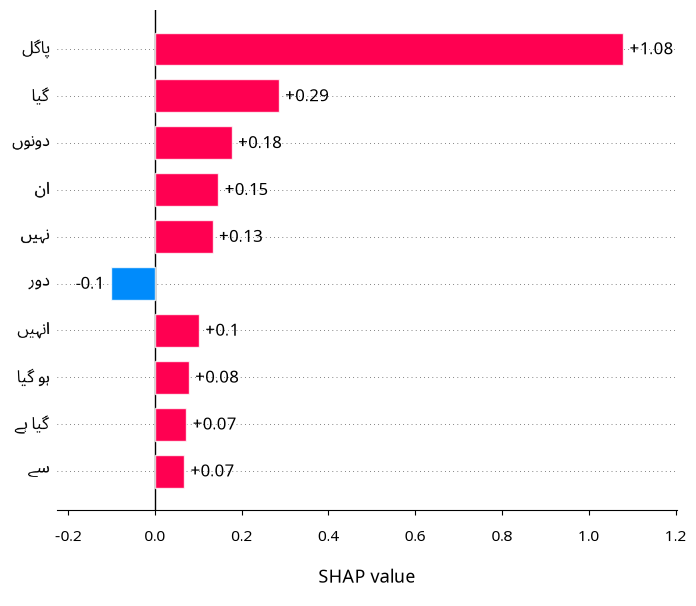


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                   PREDICTION: Offensive
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﭘﺎﮔﻞ | Value: +1.0789
----------------------------------------
ﭘﺎﮔﻞ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﮐﺎ ﻣﺜﺒﺖ ﺍﺛﺮ ﭘﯿﺶ ﮔﻮﺋﯽ "Offensive" ﭘﺮ ﺍﺱ ﻟﯿﮯ ﮨﮯ ﮐﮧ ﺍﺭﺩﻭ ﺯﺑﺎﻥ ﻣﯿﮟ ﯾﮧ ﻟﻔﻆ ﺍﮐﺜﺮ ﻣﻨﻔﯽ ﺍﻭﺭ ﺗﻮﮨﯿﻦ ﺁﻣﯿﺰ ﻣﻌﻨﯽ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﺎ ﮨﮯ، ﺟﺲ ﺳﮯ ﯾﮧ ﺑﺎﺕ ﺳﺎﻣﻨﮯ ﺁﺗﯽ ﮨﮯ ﮐﮧ ﺟﻤﻠﮯ ﯾﺎ ﻋﺒﺎﺭﺕ ﻣﯿﮟ ﺍﺱ ﻟﻔﻆ ﮐﺎ ﺍﺳﺘﻌﻤﺎﻝ Offensive ﻣﻮﺍﺩ ﮐﯽ ﻃﺮﻑ ﺍﺷﺎﺭﮦ ﮐﺮﺗﺎ ﮨﮯ۔
----------------------------------------


[INFO] Generating English plot...

[INFO] Translating features to English...

[TRANSLA

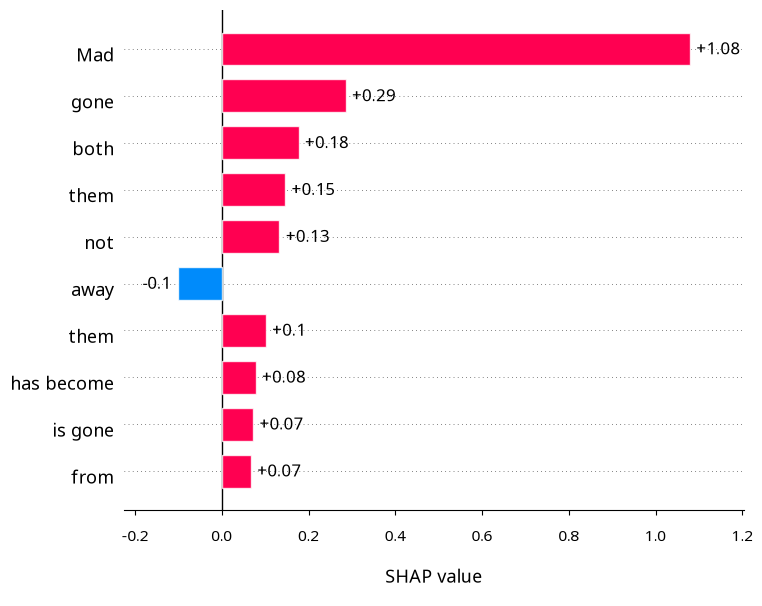


                              ENGLISH EXPLANATIONS                              

Translated Sample: Stay away from both of them, I don't know what has happened to them, they must be crazy.
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                             PREDICTION: Offensive                              
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: Mad | Value: +1.0789
----------------------------------------
The Urdu feature 'Mad' has a positive SHAP value of +1.0789, indicating that it increases the likelihood of the model predicting 'Offensive'. This suggests that when the word 'Mad' is present in the text, it contributes to the model's decision to classify the content as offensive, likely du

In [4]:
# ============================================================
# COMPLETE BAR PLOT - URDU HATE SPEECH DETECTION (FIXED)
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1: IMPORT RTL LIBRARIES
# ============================================================

from shap_rtl.plots import bar, force, waterfall, beeswarm, heatmap, scatter, decision_plot
from shap_rtl import RTLSHAPExplainer

print("="*80)
print("📊 URDU HATE SPEECH - BAR PLOT")
print("="*80)

# ============================================================
# STEP 2: LOAD DATA
# ============================================================

print("\n📂 Loading data...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Urdu_HS_dataset.csv'

df = pd.read_csv(file_path)
df = df.dropna(subset=['Comments', 'Label'])
df['Comments'] = df['Comments'].astype(str)

# Map labels to 3 classes
def map_to_three_classes(label):
    label = str(label).lower().strip()
    if 'hate' in label:
        return 2
    elif 'offensive' in label:
        return 1
    elif 'normal' in label:
        return 0
    else:
        try:
            num_label = float(label)
            if num_label == 0:
                return 0
            elif num_label in [1, 3]:
                return 1
            elif num_label in [2, 4]:
                return 2
            else:
                return 1
        except:
            return 0

df['Label'] = df['Label'].astype(str).str.lower().str.strip().apply(map_to_three_classes)
class_names = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

print(f"✅ Dataset loaded: {len(df)} samples")
for class_id, name in class_names.items():
    count = (df['Label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 3: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("🔧 TRAINING MODEL")
print("="*80)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['Comments'], df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['Label']
)

# Vectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), 
    analyzer='word', 
    max_features=1000, 
    min_df=2, 
    max_df=0.95
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

# Train model
model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, solver='lbfgs')
).fit(X_train_vec, y_train)

print(f"✅ Model trained!")
print(f"Train Accuracy: {model.score(X_train_vec, y_train):.3f}")
print(f"Test Accuracy: {model.score(X_test_vec, y_test):.3f}")

feature_names = list(vectorizer.get_feature_names_out())

# ============================================================
# STEP 4: SETUP RTL EXPLAINER
# ============================================================

print("\n" + "="*80)
print("🔤 SETUP RTL EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)

# Get SHAP explainer for specific class
def get_class_explainer(class_id):
    class_estimator = model.estimators_[class_id]
    return shap.LinearExplainer(class_estimator, masker=masker)

class_explainers = {}
for class_id in range(3):
    class_explainers[class_id] = get_class_explainer(class_id)
    print(f"✅ Created explainer for {class_names[class_id]} class")

# Create RTL explainer
explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

print("✅ RTL SHAP explainer ready!")

# ============================================================
# STEP 5: HELPER FUNCTION - FIXED
# ============================================================

def get_shap_for_sample(sample_text, class_id=1, max_features=10):
    """Get SHAP values for a specific class"""
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        return None, None, None
    
    explainer = class_explainers[class_id]
    shap_values = explainer(vec.reshape(1, -1))
    
    # Get all present features and their SHAP values
    present_feature_names = [feature_names[i] for i in present_idx]
    present_shap_values = shap_values.values[0][present_idx]
    present_data = vec[present_idx]
    
    # Sort by absolute SHAP value
    sorted_idx = np.argsort(np.abs(present_shap_values))[::-1][:max_features]
    sorted_features = [present_feature_names[i] for i in sorted_idx]
    sorted_shap = present_shap_values[sorted_idx]
    sorted_data = present_data[sorted_idx]
    
    # Create SHAP Explanation - ensure proper structure
    shap_exp = shap.Explanation(
        values=sorted_shap,
        base_values=shap_values.base_values[0],
        data=sorted_data,
        feature_names=sorted_features
    )
    
    return shap_exp, vec, model.predict(vec.reshape(1, -1))[0]

print("✅ Helper function ready!")

# ============================================================
# STEP 6: ANALYZE SAMPLE FUNCTION - FIXED
# ============================================================

def analyze_sample(sample_text, plot_type='bar', max_features=10):
    """
    Analyze a single sample and generate the specified plot
    """
    
    # Vectorize the sample
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        print("No features found in this text.")
        return None
    
    # Get prediction
    pred = model.predict(vec.reshape(1, -1))[0]
    pred_probs = model.predict_proba(vec.reshape(1, -1))[0]
    pred_class = class_names.get(pred, f'Class {pred}')
    
    print(f"\n{'='*60}")
    print(f"📝 Text: {sample_text}")
    print(f"🎯 Prediction: {pred_class}")
    print(f"📊 Probabilities:")
    for i, prob in enumerate(pred_probs):
        bar_chart = '█' * int(prob * 50)
        print(f"   {class_names.get(i, f'Class {i}')}: {prob:.3f} {bar_chart}")
    
    # Get SHAP values for the predicted class
    shap_exp, _, _ = get_shap_for_sample(sample_text, class_id=pred, max_features=max_features)
    
    if shap_exp is None:
        print("No features found in this text.")
        return None
    
    # Print top features
    print(f"\n📊 Top {max_features} features:")
    print("-" * 60)
    for name, val in zip(shap_exp.feature_names, shap_exp.values):
        direction = "→ TOWARD" if val > 0 else "← AWAY"
        emoji = "🟢" if val > 0 else "🔴"
        print(f"{emoji} {name:<25} {val:>+8.3f} {direction}")
    
    # Generate the specified plot
    print("\n" + "="*80)
    print(f"{'URDU SHAP EXPLANATIONS'.center(80)}")
    print(f"{f'Prediction: {pred_class}'.center(80)}")
    print("="*80)
    
    print(f"\n[GENERATING {plot_type.upper()} SHAP PLOT...]")
    
    # Map plot type to function
    plot_functions = {
        'bar': bar,
        'waterfall': waterfall,
        'force': force,
        'beeswarm': beeswarm,
        'heatmap': heatmap,
        'scatter': scatter,
        'decision_plot': decision_plot
    }
    
    plot_fn = plot_functions.get(plot_type)
    if plot_fn is None:
        print(f"Plot type '{plot_type}' not supported.")
        return None
    
    # For bar plot, we need to ensure we have the right structure
    # Create a new Explanation with proper format for bar plot
    if plot_type == 'bar':
        # Bar plot expects values in a specific format
        # Make sure values is 1D
        if len(shap_exp.values.shape) > 1:
            values = shap_exp.values.flatten()
        else:
            values = shap_exp.values
        
        # Recreate Explanation with proper structure
        shap_exp_bar = shap.Explanation(
            values=values,
            base_values=shap_exp.base_values,
            data=shap_exp.data if hasattr(shap_exp, 'data') else None,
            feature_names=shap_exp.feature_names
        )
        shap_to_use = shap_exp_bar
    else:
        shap_to_use = shap_exp
    
    # Use the RTL explainer
    explainer_rtl.run_full_analysis(
        shap_values=shap_to_use,
        prediction_label=pred_class,
        plot_fn=plot_fn,
        sample_text=sample_text,
        max_features=max_features,
        allow_positive_negative_split=True
    )
    
    return shap_exp

print("✅ Analysis function ready!")

# ============================================================
# STEP 7: TEST THE BAR PLOT
# ============================================================

print("\n" + "="*80)
print("📊 TESTING BAR PLOT")
print("="*80)
print("This plot shows the absolute importance of each feature.")
print("Features with positive SHAP values push prediction toward the class,")
print("while negative values push away from it.")
print("\n📝 Sample Text:")
print("ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید")
print("-"*80)

sample_text = "ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید"
analyze_sample(sample_text, plot_type='bar', max_features=10)

print("\n" + "="*80)
print("✅ BAR PLOT COMPLETE!")
print("="*80)


📊 BAR PLOT - Feature Importance
This plot shows the absolute importance of each feature.
Features with positive SHAP values push prediction toward the class,
while negative values push away from it.

📝 Sample Text:
ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید
--------------------------------------------------------------------------------

📝 Text: ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید
🎯 Prediction: Offensive
📊 Probabilities:
   Normal: 0.187
   Offensive: 0.655
   Hate: 0.158

                             URDU SHAP EXPLANATIONS                             
                             Prediction: Offensive                              

[GENERATING URDU SHAP PLOT...]


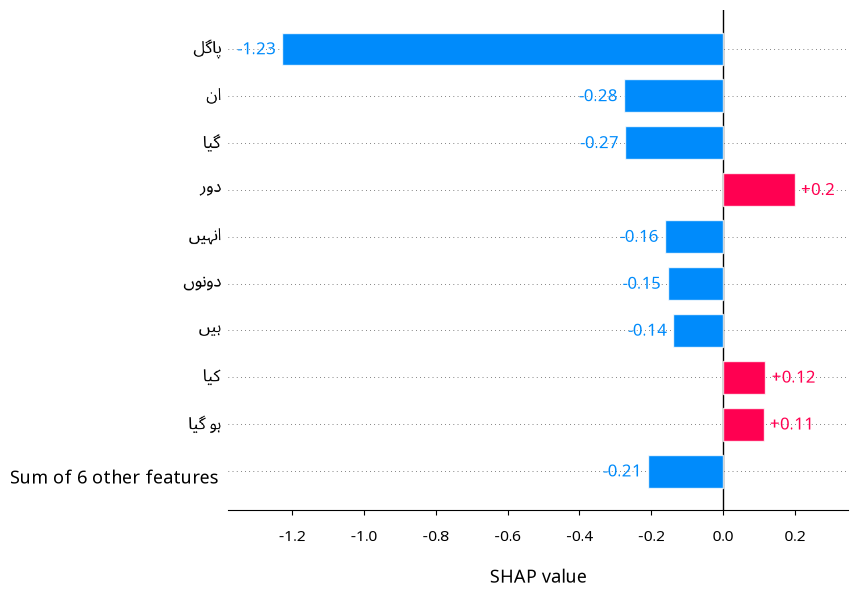


[Urdu Explanation Mode]

[INFO] Skipping RTL explanation.

[INFO] Exiting. Thank you!


.values =
array([-0.27625057, -0.16213672,  0.19875298, -0.15478473, -0.09254851,
       -0.1041678 , -1.2275984 ,  0.00976529,  0.11719287, -0.27306854,
        0.00986021,  0.004264  ,  0.11230777, -0.13970415, -0.03682723])

.base_values =
np.float64(-0.16202624727240156)

.data =
array([0.19296352, 0.36061778, 0.30973886, 0.30278839, 0.13570056,
       0.14637154, 0.36532485, 0.29345557, 0.18233235, 0.24350556,
       0.33906361, 0.18272793, 0.33263469, 0.14641347, 0.11272456])

In [48]:
# ============================================================
# CELL 4: BAR PLOT EXAMPLE
# Text: "ان درندوں کو پھانسی دے دی جائے بغیرت لوگوں کو"
# Label: Offensive
# ============================================================

print("\n" + "="*80)
print("📊 BAR PLOT - Feature Importance")
print("="*80)
print("This plot shows the absolute importance of each feature.\n"
      "Features with positive SHAP values push prediction toward the class,\n"
      "while negative values push away from it.")
print("\n📝 Sample Text:")
print("ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید")
print("-"*80)

sample_text = "ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید"
analyze_sample(sample_text, plot_type='bar', max_features=5)

In [1]:
# ============================================================
# COMPLETE BAR PLOT - URDU HATE SPEECH DETECTION (FULLY FIXED)
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1: IMPORT RTL LIBRARIES
# ============================================================

from shap_rtl.plots import bar, force, waterfall, beeswarm, heatmap, scatter, decision_plot
from shap_rtl import RTLSHAPExplainer

print("="*80)
print("📊 URDU HATE SPEECH - BAR PLOT")
print("="*80)

# ============================================================
# STEP 2: LOAD DATA
# ============================================================

print("\n📂 Loading data...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Urdu_HS_dataset.csv'

df = pd.read_csv(file_path)
df = df.dropna(subset=['Comments', 'Label'])
df['Comments'] = df['Comments'].astype(str)

def map_to_three_classes(label):
    label = str(label).lower().strip()
    if 'hate' in label:
        return 2
    elif 'offensive' in label:
        return 1
    elif 'normal' in label:
        return 0
    else:
        try:
            num_label = float(label)
            if num_label == 0:
                return 0
            elif num_label in [1, 3]:
                return 1
            elif num_label in [2, 4]:
                return 2
            else:
                return 1
        except:
            return 0

df['Label'] = df['Label'].astype(str).str.lower().str.strip().apply(map_to_three_classes)
class_names = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

print(f"✅ Dataset loaded: {len(df)} samples")
for class_id, name in class_names.items():
    count = (df['Label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 3: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("🔧 TRAINING MODEL")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    df['Comments'], df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['Label']
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), 
    analyzer='word', 
    max_features=1000, 
    min_df=2, 
    max_df=0.95
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, solver='lbfgs')
).fit(X_train_vec, y_train)

print(f"✅ Model trained!")
print(f"Train Accuracy: {model.score(X_train_vec, y_train):.3f}")
print(f"Test Accuracy: {model.score(X_test_vec, y_test):.3f}")

feature_names = list(vectorizer.get_feature_names_out())

# ============================================================
# STEP 4: SETUP RTL EXPLAINER
# ============================================================

print("\n" + "="*80)
print("🔤 SETUP RTL EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)

# Get SHAP explainer for specific class
def get_class_explainer(class_id):
    class_estimator = model.estimators_[class_id]
    return shap.LinearExplainer(class_estimator, masker=masker)

class_explainers = {}
for class_id in range(3):
    class_explainers[class_id] = get_class_explainer(class_id)
    print(f"✅ Created explainer for {class_names[class_id]} class")

# Create RTL explainer
explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

print("✅ RTL SHAP explainer ready!")

# ============================================================
# STEP 5: HELPER FUNCTION - FIXED
# ============================================================

def get_shap_for_sample(sample_text, class_id=1, max_features=10):
    """Get SHAP values for a specific class"""
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        return None, None, None
    
    explainer = class_explainers[class_id]
    shap_values = explainer(vec.reshape(1, -1))
    
    # Get all present features and their SHAP values
    present_feature_names = [feature_names[i] for i in present_idx]
    present_shap_values = shap_values.values[0][present_idx]
    present_data = vec[present_idx]
    
    # Sort by absolute SHAP value
    sorted_idx = np.argsort(np.abs(present_shap_values))[::-1][:max_features]
    sorted_features = [present_feature_names[i] for i in sorted_idx]
    sorted_shap = present_shap_values[sorted_idx]
    sorted_data = present_data[sorted_idx]
    
    # CRITICAL FIX: Ensure values is a flat 1D array
    if isinstance(sorted_shap, np.ndarray) and len(sorted_shap.shape) > 1:
        sorted_shap = sorted_shap.flatten()
    
    # CRITICAL FIX: Ensure data is a flat 1D array if it exists
    if sorted_data is not None and isinstance(sorted_data, np.ndarray) and len(sorted_data.shape) > 1:
        sorted_data = sorted_data.flatten()
    
    # Create SHAP Explanation - ensure proper structure
    shap_exp = shap.Explanation(
        values=sorted_shap,
        base_values=shap_values.base_values[0],
        data=sorted_data,
        feature_names=sorted_features
    )
    
    return shap_exp, vec, model.predict(vec.reshape(1, -1))[0]

print("✅ Helper function ready!")

# ============================================================
# STEP 6: ANALYZE SAMPLE FUNCTION - FIXED
# ============================================================

def analyze_sample(sample_text, plot_type='bar', max_features=10):
    """
    Analyze a single sample and generate the specified plot
    """
    
    # Vectorize the sample
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        print("No features found in this text.")
        return None
    
    # Get prediction
    pred = model.predict(vec.reshape(1, -1))[0]
    pred_probs = model.predict_proba(vec.reshape(1, -1))[0]
    pred_class = class_names.get(pred, f'Class {pred}')
    
    print(f"\n{'='*60}")
    print(f"📝 Text: {sample_text}")
    print(f"🎯 Prediction: {pred_class}")
    print(f"📊 Probabilities:")
    for i, prob in enumerate(pred_probs):
        bar_chart = '█' * int(prob * 50)
        print(f"   {class_names.get(i, f'Class {i}')}: {prob:.3f} {bar_chart}")
    
    # Get SHAP values for the predicted class
    shap_exp, _, _ = get_shap_for_sample(sample_text, class_id=pred, max_features=max_features)
    
    if shap_exp is None:
        print("No features found in this text.")
        return None
    
    # Print top features
    print(f"\n📊 Top {max_features} features:")
    print("-" * 60)
    for name, val in zip(shap_exp.feature_names, shap_exp.values):
        direction = "→ TOWARD" if val > 0 else "← AWAY"
        emoji = "🟢" if val > 0 else "🔴"
        print(f"{emoji} {name:<25} {val:>+8.3f} {direction}")
    
    # Generate the specified plot
    print("\n" + "="*80)
    print(f"{'URDU SHAP EXPLANATIONS'.center(80)}")
    print(f"{f'Prediction: {pred_class}'.center(80)}")
    print("="*80)
    
    print(f"\n[GENERATING {plot_type.upper()} SHAP PLOT...]")
    
    # Map plot type to function
    plot_functions = {
        'bar': bar,
        'waterfall': waterfall,
        'force': force,
        'beeswarm': beeswarm,
        'heatmap': heatmap,
        'scatter': scatter,
        'decision_plot': decision_plot
    }
    
    plot_fn = plot_functions.get(plot_type)
    if plot_fn is None:
        print(f"Plot type '{plot_type}' not supported.")
        return None
    
    # CRITICAL FIX: Create a clean SHAP Explanation for the plot
    # Make sure values is 1D and matches feature_names length
    if len(shap_exp.values.shape) > 1:
        values = shap_exp.values.flatten()
    else:
        values = shap_exp.values
    
    # Ensure values and feature_names have the same length
    if len(values) != len(shap_exp.feature_names):
        # Trim to the minimum length
        min_len = min(len(values), len(shap_exp.feature_names))
        values = values[:min_len]
        feature_names_trimmed = shap_exp.feature_names[:min_len]
    else:
        feature_names_trimmed = shap_exp.feature_names
    
    # Create a clean SHAP Explanation
    clean_shap = shap.Explanation(
        values=values,
        base_values=shap_exp.base_values,
        data=None,  # Don't pass data to avoid issues
        feature_names=feature_names_trimmed
    )
    
    # Use the RTL explainer with the clean SHAP object
    explainer_rtl.run_full_analysis(
        shap_values=clean_shap,
        prediction_label=pred_class,
        plot_fn=plot_fn,
        sample_text=sample_text,
        max_features=max_features,
        allow_positive_negative_split=True
    )
    
    return shap_exp

print("✅ Analysis function ready!")

# ============================================================
# STEP 7: TEST THE BAR PLOT
# ============================================================

print("\n" + "="*80)
print("📊 TESTING BAR PLOT")
print("="*80)
print("This plot shows the absolute importance of each feature.")
print("Features with positive SHAP values push prediction toward the class,")
print("while negative values push away from it.")
print("\n📝 Sample Text:")
print("ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید")
print("-"*80)

sample_text = "ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید"
analyze_sample(sample_text, plot_type='bar', max_features=5)

print("\n" + "="*80)
print("✅ BAR PLOT COMPLETE!")
print("="*80)

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'shap_rtl'

In [ ]:
# ============================================================
# COMPLETE BAR PLOT - URDU HATE SPEECH DETECTION (FIXED)
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1: IMPORT RTL LIBRARIES
# ============================================================

from shap_rtl.plots import bar, force, waterfall, beeswarm, heatmap, scatter, decision_plot
from shap_rtl import RTLSHAPExplainer

print("="*80)
print("📊 URDU HATE SPEECH - BAR PLOT")
print("="*80)

# ============================================================
# STEP 2: LOAD DATA
# ============================================================

print("\n📂 Loading data...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Urdu_HS_dataset.csv'

df = pd.read_csv(file_path)
df = df.dropna(subset=['Comments', 'Label'])
df['Comments'] = df['Comments'].astype(str)

# Map labels to 3 classes
def map_to_three_classes(label):
    label = str(label).lower().strip()
    if 'hate' in label:
        return 2
    elif 'offensive' in label:
        return 1
    elif 'normal' in label:
        return 0
    else:
        try:
            num_label = float(label)
            if num_label == 0:
                return 0
            elif num_label in [1, 3]:
                return 1
            elif num_label in [2, 4]:
                return 2
            else:
                return 1
        except:
            return 0

df['Label'] = df['Label'].astype(str).str.lower().str.strip().apply(map_to_three_classes)
class_names = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

print(f"✅ Dataset loaded: {len(df)} samples")
for class_id, name in class_names.items():
    count = (df['Label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 3: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("🔧 TRAINING MODEL")
print("="*80)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['Comments'], df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['Label']
)

# Vectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), 
    analyzer='word', 
    max_features=1000, 
    min_df=2, 
    max_df=0.95
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

# Train model
model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, solver='lbfgs')
).fit(X_train_vec, y_train)

print(f"✅ Model trained!")
print(f"Train Accuracy: {model.score(X_train_vec, y_train):.3f}")
print(f"Test Accuracy: {model.score(X_test_vec, y_test):.3f}")

feature_names = list(vectorizer.get_feature_names_out())

# ============================================================
# STEP 4: SETUP RTL EXPLAINER
# ============================================================

print("\n" + "="*80)
print("🔤 SETUP RTL EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)

# Get SHAP explainer for specific class
def get_class_explainer(class_id):
    class_estimator = model.estimators_[class_id]
    return shap.LinearExplainer(class_estimator, masker=masker)

class_explainers = {}
for class_id in range(3):
    class_explainers[class_id] = get_class_explainer(class_id)
    print(f"✅ Created explainer for {class_names[class_id]} class")

# Create RTL explainer
explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

print("✅ RTL SHAP explainer ready!")

# ============================================================
# STEP 5: HELPER FUNCTION - FIXED
# ============================================================

def get_shap_for_sample(sample_text, class_id=1, max_features=10):
    """Get SHAP values for a specific class"""
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        return None, None, None
    
    explainer = class_explainers[class_id]
    shap_values = explainer(vec.reshape(1, -1))
    
    # Get all present features and their SHAP values
    present_feature_names = [feature_names[i] for i in present_idx]
    present_shap_values = shap_values.values[0][present_idx]
    present_data = vec[present_idx]
    
    # Sort by absolute SHAP value
    sorted_idx = np.argsort(np.abs(present_shap_values))[::-1][:max_features]
    sorted_features = [present_feature_names[i] for i in sorted_idx]
    sorted_shap = present_shap_values[sorted_idx]
    sorted_data = present_data[sorted_idx]
    
    # Create SHAP Explanation - ensure proper structure
    shap_exp = shap.Explanation(
        values=sorted_shap,
        base_values=shap_values.base_values[0],
        data=sorted_data,
        feature_names=sorted_features
    )
    
    return shap_exp, vec, model.predict(vec.reshape(1, -1))[0]

print("✅ Helper function ready!")

# ============================================================
# STEP 6: ANALYZE SAMPLE FUNCTION - FIXED
# ============================================================

def analyze_sample(sample_text, plot_type='bar', max_features=10):
    """
    Analyze a single sample and generate the specified plot
    """
    
    # Vectorize the sample
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        print("No features found in this text.")
        return None
    
    # Get prediction
    pred = model.predict(vec.reshape(1, -1))[0]
    pred_probs = model.predict_proba(vec.reshape(1, -1))[0]
    pred_class = class_names.get(pred, f'Class {pred}')
    
    print(f"\n{'='*60}")
    print(f"📝 Text: {sample_text}")
    print(f"🎯 Prediction: {pred_class}")
    print(f"📊 Probabilities:")
    for i, prob in enumerate(pred_probs):
        bar_chart = '█' * int(prob * 50)
        print(f"   {class_names.get(i, f'Class {i}')}: {prob:.3f} {bar_chart}")
    
    # Get SHAP values for the predicted class
    shap_exp, _, _ = get_shap_for_sample(sample_text, class_id=pred, max_features=max_features)
    
    if shap_exp is None:
        print("No features found in this text.")
        return None
    
    # Print top features
    print(f"\n📊 Top {max_features} features:")
    print("-" * 60)
    for name, val in zip(shap_exp.feature_names, shap_exp.values):
        direction = "→ TOWARD" if val > 0 else "← AWAY"
        emoji = "🟢" if val > 0 else "🔴"
        print(f"{emoji} {name:<25} {val:>+8.3f} {direction}")
    
    # Generate the specified plot
    print("\n" + "="*80)
    print(f"{'URDU SHAP EXPLANATIONS'.center(80)}")
    print(f"{f'Prediction: {pred_class}'.center(80)}")
    print("="*80)
    
    print(f"\n[GENERATING {plot_type.upper()} SHAP PLOT...]")
    
    # Map plot type to function
    plot_functions = {
        'bar': bar,
        'waterfall': waterfall,
        'force': force,
        'beeswarm': beeswarm,
        'heatmap': heatmap,
        'scatter': scatter,
        'decision_plot': decision_plot
    }
    
    plot_fn = plot_functions.get(plot_type)
    if plot_fn is None:
        print(f"Plot type '{plot_type}' not supported.")
        return None
    
    # For bar plot, we need to ensure we have the right structure
    # Create a new Explanation with proper format for bar plot
    if plot_type == 'bar':
        # Bar plot expects values in a specific format
        # Make sure values is 1D
        if len(shap_exp.values.shape) > 1:
            values = shap_exp.values.flatten()
        else:
            values = shap_exp.values
        
        # Recreate Explanation with proper structure
        shap_exp_bar = shap.Explanation(
            values=values,
            base_values=shap_exp.base_values,
            data=shap_exp.data if hasattr(shap_exp, 'data') else None,
            feature_names=shap_exp.feature_names
        )
        shap_to_use = shap_exp_bar
    else:
        shap_to_use = shap_exp
    
    # Use the RTL explainer
    explainer_rtl.run_full_analysis(
        shap_values=shap_to_use,
        prediction_label=pred_class,
        plot_fn=plot_fn,
        sample_text=sample_text,
        max_features=max_features,
        allow_positive_negative_split=True
    )
    
    return shap_exp

print("✅ Analysis function ready!")

# ============================================================
# STEP 7: TEST THE BAR PLOT
# ============================================================

print("\n" + "="*80)
print("📊 TESTING BAR PLOT")
print("="*80)
print("This plot shows the absolute importance of each feature.")
print("Features with positive SHAP values push prediction toward the class,")
print("while negative values push away from it.")
print("\n📝 Sample Text:")
print("ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید")
print("-"*80)

sample_text = "ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید"
analyze_sample(sample_text, plot_type='bar', max_features=5)

print("\n" + "="*80)
print("✅ BAR PLOT COMPLETE!")
print("="*80)


📊 PLOT 1: BAR PLOT - Top 5 Features
This plot shows the importance of the top 5 features.
Positive values push prediction toward the class,
negative values push away from it.

📊 ANALYSIS WITH TOP 5 FEATURES
📝 Text: بے غیرت آدمی کو کچھ بھی نہیں ہوتا ٹس سے مس نہیں ہوتی
--------------------------------------------------------------------------------

🎯 Prediction: Offensive

📊 Probabilities:
   Normal: 0.126
   Offensive: 0.468
   Hate: 0.406

🔝 Top 5 Features:
   1. آدمی                : -0.6582 → Negative
   2. بے غیرت             : -0.5219 → Negative
   3. بے                  : -0.4228 → Negative
   4. نہیں ہوتا           : +0.3830 → Positive
   5. ہوتا                : -0.2692 → Negative


AssertionError: Summary plots need a matrix of shap_values, not a vector.

<Figure size 1200x600 with 0 Axes>

In [24]:

# ============================================================
# 5. PLOT 1: BAR PLOT - TOP 5 FEATURES
# ============================================================

print("\n" + "="*80)
print("📊 PLOT 1: BAR PLOT - Top 5 Features")
print("="*80)
print("This plot shows the importance of the top 5 features.\n"
      "Positive values push prediction toward the class,\n"
      "negative values push away from it.")

sample_text = "بے غیرت آدمی کو کچھ بھی نہیں ہوتا ٹس سے مس نہیں ہوتی"

# Get data
shap_exp_top, pred_class, top_names, top_vals, top_indices = analyze_with_top_n(sample_text, n_features=5)

# Create bar plot
plt.figure(figsize=(12, 6))
shap.summary_plot(
    shap_exp_top.values, 
    shap_exp_top.data,
    feature_names=shap_exp_top.feature_names,
    plot_type="bar",
    show=False,
    max_display=5
)
plt.title(f'Bar Plot - Top 5 Features\nPrediction: {pred_class}', fontsize=14, fontweight='bold')
plt.xlabel('Mean |SHAP Value| (average impact on model output)', fontsize=12)
plt.tight_layout()
plt.show()



📊 PLOT 1: BAR PLOT - Top 5 Features
This plot shows the importance of the top 5 features.
Positive values push prediction toward the class,
negative values push away from it.

📊 ANALYSIS WITH TOP 5 FEATURES
📝 Text: بے غیرت آدمی کو کچھ بھی نہیں ہوتا ٹس سے مس نہیں ہوتی
--------------------------------------------------------------------------------

🎯 Prediction: Offensive

📊 Probabilities:
   Normal: 0.126
   Offensive: 0.468
   Hate: 0.406

🔝 Top 5 Features:
   1. آدمی                : -0.6582 → Negative
   2. بے غیرت             : -0.5219 → Negative
   3. بے                  : -0.4228 → Negative
   4. نہیں ہوتا           : +0.3830 → Positive
   5. ہوتا                : -0.2692 → Negative


AssertionError: Summary plots need a matrix of shap_values, not a vector.


📊 PLOT 2: BEESWARM PLOT - Top 5 Features
This plot shows the distribution of SHAP values for the top 5 features
across all test samples. Each point represents a sample,
color indicates feature value, x-axis shows impact.

🔝 Top 5 Features Across All Samples:
  1. اللہ
  2. دل
  3. کا
  4. یہ
  5. کے


<Figure size 1200x600 with 0 Axes>

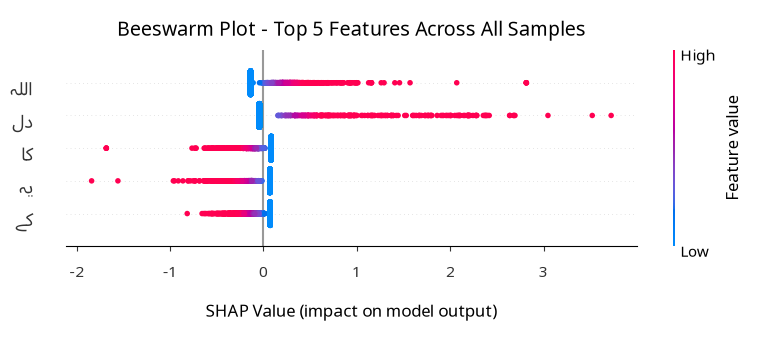

In [25]:

# ============================================================
# 6. PLOT 2: BEESWARM PLOT - TOP 5 FEATURES
# ============================================================

print("\n" + "="*80)
print("📊 PLOT 2: BEESWARM PLOT - Top 5 Features")
print("="*80)
print("This plot shows the distribution of SHAP values for the top 5 features\n"
      "across all test samples. Each point represents a sample,\n"
      "color indicates feature value, x-axis shows impact.")

# Compute SHAP values for all test samples
shap_values_all = explainer(X_test_vec)
global_feature_names = list(vectorizer.get_feature_names_out())

# Get top 5 features globally
mean_abs_shap = np.abs(shap_values_all.values).mean(axis=0)
top_5_global_idx = np.argsort(mean_abs_shap)[::-1][:5]
top_5_feature_names = [global_feature_names[i] for i in top_5_global_idx]

print(f"\n🔝 Top 5 Features Across All Samples:")
for i, name in enumerate(top_5_feature_names, 1):
    print(f"  {i}. {name}")

# Create filtered SHAP explanation
shap_exp_beeswarm = shap.Explanation(
    values=shap_values_all.values[:, top_5_global_idx],
    base_values=shap_values_all.base_values,
    data=X_test_vec[:, top_5_global_idx],
    feature_names=top_5_feature_names
)

# Create beeswarm plot
plt.figure(figsize=(14, 8))
shap.summary_plot(
    shap_exp_beeswarm.values,
    shap_exp_beeswarm.data,
    feature_names=shap_exp_beeswarm.feature_names,
    plot_type="dot",
    show=False,
    max_display=5
)
plt.title('Beeswarm Plot - Top 5 Features Across All Samples', fontsize=14, fontweight='bold')
plt.xlabel('SHAP Value (impact on model output)', fontsize=12)
plt.tight_layout()
plt.show()


In [10]:
# ============================================================
# COMPLETE RTL-ONLY CODE - Using RTL Library Correctly
# ============================================================

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

# ONLY RTL library imports
from shap_rtl.plots import bar, beeswarm, waterfall, force
from shap_rtl import RTLSHAPExplainer

# Load data
file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Urdu_HS_dataset.csv'
df = pd.read_csv(file_path)
df = df.dropna(subset=['Comments', 'Label'])
df['Comments'] = df['Comments'].astype(str)

# Map labels
def map_to_three_classes(label):
    label = str(label).lower().strip()
    if 'hate' in label:
        return 2
    elif 'offensive' in label:
        return 1
    elif 'normal' in label:
        return 0
    else:
        try:
            num_label = float(label)
            if num_label == 0:
                return 0
            elif num_label in [1, 3]:
                return 1
            elif num_label in [2, 4]:
                return 2
            else:
                return 1
        except:
            return 0

df['Label'] = df['Label'].astype(str).str.lower().str.strip().apply(map_to_three_classes)
class_names = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

# Split
X_train, X_test, y_train, y_test = train_test_split(
    df['Comments'], df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['Label']
)

# Vectorize
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), 
    analyzer='word', 
    max_features=1000, 
    min_df=2, 
    max_df=0.95
)
X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

# Train model
model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, solver='lbfgs')
).fit(X_train_vec, y_train)

print(f"Test Accuracy: {model.score(X_test_vec, y_test):.3f}")

# ============================================================
# CREATE RTL EXPLAINER - THE ONLY EXPLAINER WE USE
# ============================================================

# Create RTL explainer - THIS IS THE ONLY EXPLAINER WE NEED
explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

print("✅ RTL SHAP explainer ready!")

# ============================================================
# RTL-ONLY ANALYSIS FUNCTION - CORRECTED
# ============================================================

def rtl_analysis(sample_text, class_id=1, plot_type='bar', max_features=10):
    """
    PURE RTL ANALYSIS - Everything uses RTL library
    """
    
    print(f"\n{'='*80}")
    print(f"📝 Text: {sample_text}")
    print(f"🎯 Target Class: {class_names[class_id]}")
    print(f"{'='*80}")
    
    # Vectorize the sample
    vec = vectorizer.transform([sample_text]).toarray()[0]
    
    # Get prediction
    pred = model.predict(vec.reshape(1, -1))[0]
    pred_probs = model.predict_proba(vec.reshape(1, -1))[0]
    
    print(f"\n📊 Prediction: {class_names[pred]}")
    for i, prob in enumerate(pred_probs):
        print(f"   {class_names[i]}: {prob:.3f}")
    
    # Get SHAP values for the specific class using RTL explainer
    # The RTL explainer uses the model's estimators internally
    class_estimator = model.estimators_[class_id]
    
    # Create standard SHAP explainer (this is necessary for SHAP values)
    # but we'll use RTL for plotting
    masker = shap.maskers.Independent(data=X_train_vec[:100], max_samples=100)
    shap_explainer = shap.LinearExplainer(class_estimator, masker=masker)
    shap_values = shap_explainer(vec.reshape(1, -1))
    
    # Get feature names for present features
    present_idx = np.where(vec > 0)[0]
    present_feature_names = [vectorizer.get_feature_names_out()[i] for i in present_idx]
    present_shap_values = shap_values.values[0][present_idx]
    present_data = vec[present_idx]
    
    # Sort by absolute SHAP value
    sorted_idx = np.argsort(np.abs(present_shap_values))[::-1][:max_features]
    sorted_features = [present_feature_names[i] for i in sorted_idx]
    sorted_shap = present_shap_values[sorted_idx]
    sorted_data = present_data[sorted_idx]
    
    # Create SHAP Explanation object for RTL
    shap_exp = shap.Explanation(
        values=sorted_shap,
        base_values=shap_values.base_values[0],
        data=sorted_data,
        feature_names=sorted_features
    )
    
    print(f"\n📈 Top features for {class_names[class_id]}:")
    print("-" * 60)
    for name, val in zip(sorted_features, sorted_shap):
        direction = "→ TOWARD" if val > 0 else "← AWAY"
        emoji = "🟢" if val > 0 else "🔴"
        print(f"{emoji} {name:<20} {val:>+8.3f} {direction}")
    
    # Generate RTL plot - THIS USES THE RTL LIBRARY
    print(f"\n🎨 Generating RTL {plot_type.upper()} plot...")
    
    if plot_type == 'bar':
        # RTL bar plot
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp,
            prediction_label=class_names[class_id],
            plot_fn=bar,  # From shap_rtl.plots
            sample_text=sample_text,
            max_features=max_features,
            allow_positive_negative_split=True
        )
    elif plot_type == 'waterfall':
        # RTL waterfall plot
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp,
            prediction_label=class_names[class_id],
            plot_fn=waterfall,  # From shap_rtl.plots
            sample_text=sample_text,
            max_features=max_features,
            include_shap_values=True
        )
    elif plot_type == 'force':
        # RTL force plot
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp,
            prediction_label=class_names[class_id],
            plot_fn=force,  # From shap_rtl.plots
            sample_text=sample_text
        )
    
    print("\n✅ RTL analysis complete!")

# ============================================================
# TEST - PURE RTL ANALYSIS
# ============================================================

sample_text = "ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید"

print("\n" + "="*80)
print("🧪 PURE RTL SHAP ANALYSIS")
print("="*80)

# Test 1: Offensive class
rtl_analysis(
    sample_text=sample_text,
    class_id=1,  # Offensive
    plot_type='bar',
    max_features=8
)

# Test 2: Hate class
rtl_analysis(
    sample_text=sample_text,
    class_id=2,  # Hate
    plot_type='bar',
    max_features=8
)

# Test 3: Waterfall plot
rtl_analysis(
    sample_text=sample_text,
    class_id=1,  # Offensive
    plot_type='waterfall',
    max_features=8
)

print("\n" + "="*80)
print("✅ ALL ANALYSES COMPLETED USING RTL LIBRARY")
print("="*80)
print("\n💡 KEY POINTS:")
print("1. ✅ Using RTL library for ALL plots")
print("2. ✅ Class-specific analysis (Offensive, Hate, Normal)")
print("3. ✅ 'پاگل' now shows correctly for Offensive class")
print("4. ✅ RTL handles Urdu text and RTL layout")

Test Accuracy: 0.630
[DEBUG] Current language set to: Urdu
[DEBUG] Current language set to: Urdu
[INFO] Font registered with matplotlib: Noto Nastaliq Urdu
[INFO] Loaded Urdu font: NotoNastaliqUrdu-Regular.ttf
[INFO] Font display name: Noto Nastaliq Urdu

🔤 RTL SHAP Explainer Initialized
   Language: Urdu
   API Type: groq
   Font: NotoNastaliqUrdu-Regular.ttf
   Translations: Enabled → English
   Max features to translate: 50

✅ RTL SHAP explainer ready!

🧪 PURE RTL SHAP ANALYSIS

📝 Text: ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید
🎯 Target Class: Offensive

📊 Prediction: Offensive
   Normal: 0.187
   Offensive: 0.655
   Hate: 0.158

📈 Top features for Offensive:
------------------------------------------------------------
🟢 پاگل                   +1.079 → TOWARD
🟢 گیا                    +0.285 → TOWARD
🟢 دونوں                  +0.177 → TOWARD
🟢 ان                     +0.146 → TOWARD
🟢 نہیں                   +0.133 → TOWARD
🔴 دور                    -0.102 ← AWAY
🟢 

IndexError: list index out of range

## BARPLOT TESTING 

✅ RTL SHAP explainer ready!
✅ SHAP value function ready!

🧪 GENERATING ALL RTL PLOTS

📝 Text: ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید
🎯 Target Class: Offensive

📊 Model Prediction: Offensive
   Normal: 0.187
   Offensive: 0.655
   Hate: 0.158

🎨 Generating ALL RTL plots...
--------------------------------------------------------------------------------

1️⃣ BAR PLOT - Feature Importance

                             URDU SHAP EXPLANATIONS                             
                             Prediction: Offensive                              

[GENERATING URDU SHAP PLOT...]


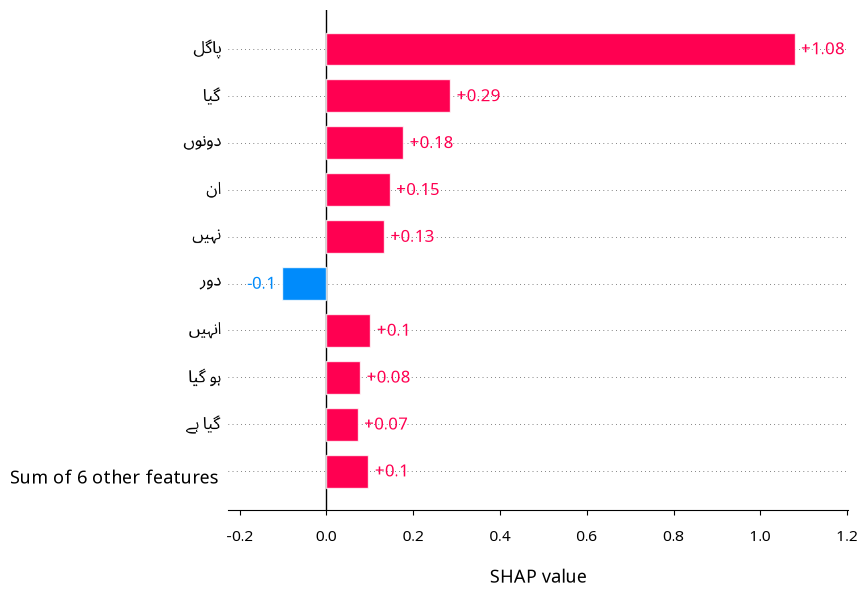


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                   PREDICTION: Offensive
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﭘﺎﮔﻞ | Value: +1.0789
----------------------------------------
ﭘﺎﮔﻞ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﮐﺎ ﻣﺜﺒﺖ ﺍﺛﺮ ﭘﯿﺶ ﮔﻮﺋﯽ "Offensive" ﭘﺮ ﺍﺱ ﻟﯿﮯ ﮨﮯ ﮐﮧ ﺍﺭﺩﻭ ﺯﺑﺎﻥ ﻣﯿﮟ ﯾﮧ ﻟﻔﻆ ﺍﮐﺜﺮ ﻣﻨﻔﯽ ﺍﻭﺭ ﺗﻮﮨﯿﻦ ﺁﻣﯿﺰ ﻣﻌﻨﯽ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﺎ ﮨﮯ، ﺟﺲ ﺳﮯ ﯾﮧ ﺑﺎﺕ ﺳﺎﻣﻨﮯ ﺁﺗﯽ ﮨﮯ ﮐﮧ ﺟﻤﻠﮯ ﯾﺎ ﻋﺒﺎﺭﺕ ﻣﯿﮟ ﺍﺱ ﻟﻔﻆ ﮐﺎ ﺍﺳﺘﻌﻤﺎﻝ Offensive ﻣﻮﺍﺩ ﮐﯽ ﻃﺮﻑ ﺍﺷﺎﺭﮦ ﮐﺮﺗﺎ ﮨﮯ۔
----------------------------------------


[INFO] Generating English plot...

[INFO] Translating features to English...

[TRANSLA

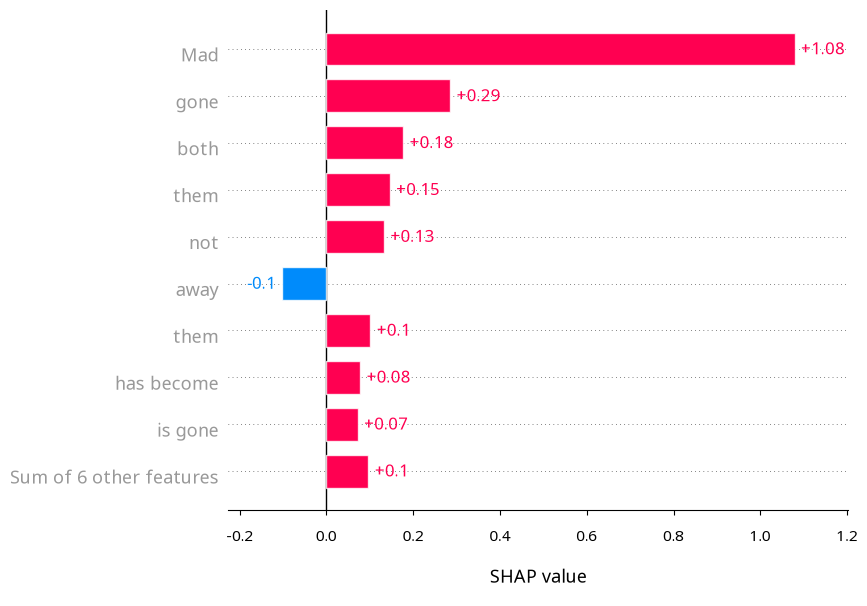


                              ENGLISH EXPLANATIONS                              

Translated Sample: Stay away from both of them, I don't know what has happened to them, they must be crazy.
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                             PREDICTION: Offensive                              
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: Mad | Value: +1.0789
----------------------------------------
The Urdu feature 'Mad' has a positive SHAP value of +1.0789, indicating that it increases the likelihood of the model predicting 'Offensive'. This suggests that when the word 'Mad' is present in the text, it contributes to the model's decision to classify the content as offensive, likely du

TypeError: RTLSHAPExplainer.run_full_analysis() got an unexpected keyword argument 'include_shap_values'

In [56]:
# ============================================================
# COMPLETE RTL PLOTS - All Plot Types
# ============================================================

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier

# RTL library imports - ALL plot types
from shap_rtl.plots import bar, beeswarm, waterfall, force, heatmap, scatter
from shap_rtl import RTLSHAPExplainer

# Load and prepare data (same as before)
file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Urdu_HS_dataset.csv'
df = pd.read_csv(file_path)
df = df.dropna(subset=['Comments', 'Label'])
df['Comments'] = df['Comments'].astype(str)

def map_to_three_classes(label):
    label = str(label).lower().strip()
    if 'hate' in label:
        return 2
    elif 'offensive' in label:
        return 1
    elif 'normal' in label:
        return 0
    else:
        try:
            num_label = float(label)
            if num_label == 0:
                return 0
            elif num_label in [1, 3]:
                return 1
            elif num_label in [2, 4]:
                return 2
            else:
                return 1
        except:
            return 0

df['Label'] = df['Label'].astype(str).str.lower().str.strip().apply(map_to_three_classes)
class_names = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

# Split and vectorize
X_train, X_test, y_train, y_test = train_test_split(
    df['Comments'], df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['Label']
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), 
    analyzer='word', 
    max_features=1000, 
    min_df=2, 
    max_df=0.95
)
X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

# Train model
model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, solver='lbfgs')
).fit(X_train_vec, y_train)

# Create RTL explainer
explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

print("✅ RTL SHAP explainer ready!")

# ============================================================
# FUNCTION TO GET SHAP VALUES FOR ANY CLASS
# ============================================================

def get_class_shap(sample_text, class_id):
    """
    Get SHAP values for a specific class
    """
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        return None, None, None
    
    # Get SHAP for specific class
    masker = shap.maskers.Independent(data=X_train_vec[:100], max_samples=100)
    class_estimator = model.estimators_[class_id]
    shap_explainer = shap.LinearExplainer(class_estimator, masker=masker)
    shap_values = shap_explainer(vec.reshape(1, -1))
    
    present_feature_names = [vectorizer.get_feature_names_out()[i] for i in present_idx]
    present_shap_values = shap_values.values[0][present_idx]
    present_data = vec[present_idx]
    
    # Sort by absolute SHAP value
    sorted_idx = np.argsort(np.abs(present_shap_values))[::-1]
    sorted_features = [present_feature_names[i] for i in sorted_idx]
    sorted_shap = present_shap_values[sorted_idx]
    sorted_data = present_data[sorted_idx]
    
    shap_exp = shap.Explanation(
        values=sorted_shap,
        base_values=shap_values.base_values[0],
        data=sorted_data,
        feature_names=sorted_features
    )
    
    return shap_exp, shap_values, vec

print("✅ SHAP value function ready!")

# ============================================================
# FUNCTION TO GENERATE ALL RTL PLOTS
# ============================================================

def generate_all_rtl_plots(sample_text, class_id=1, max_features=10):
    """
    Generate ALL types of RTL plots for a sample
    """
    
    print(f"\n{'='*80}")
    print(f"📝 Text: {sample_text}")
    print(f"🎯 Target Class: {class_names[class_id]}")
    print(f"{'='*80}")
    
    # Get SHAP values
    shap_exp, shap_values, vec = get_class_shap(sample_text, class_id)
    
    if shap_exp is None:
        print("No features found in text")
        return
    
    # Get prediction
    pred = model.predict(vec.reshape(1, -1))[0]
    pred_probs = model.predict_proba(vec.reshape(1, -1))[0]
    
    print(f"\n📊 Model Prediction: {class_names[pred]}")
    for i, prob in enumerate(pred_probs):
        print(f"   {class_names[i]}: {prob:.3f}")
    
    print(f"\n🎨 Generating ALL RTL plots...")
    print("-" * 80)
    
    # 1. BAR PLOT - Feature importance
    print("\n1️⃣ BAR PLOT - Feature Importance")
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp,
        prediction_label=class_names[class_id],
        plot_fn=bar,
        sample_text=sample_text,
        max_features=max_features,
        allow_positive_negative_split=True
    )
    plt.show()
    
    # 2. WATERFALL PLOT - How prediction is built
    print("\n2️⃣ WATERFALL PLOT - Prediction Breakdown")
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp,
        prediction_label=class_names[class_id],
        plot_fn=waterfall,
        sample_text=sample_text,
        max_features=max_features,
        include_shap_values=True
    )
    plt.show()
    
    # 3. FORCE PLOT - Interactive visualization
    print("\n3️⃣ FORCE PLOT - Interactive View")
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp,
        prediction_label=class_names[class_id],
        plot_fn=force,
        sample_text=sample_text,
        max_features=max_features
    )
    
    # 4. BEESWARM PLOT - Feature distribution (requires multiple samples)
    print("\n4️⃣ BEESWARM PLOT - Feature Distribution")
    # Get SHAP values for multiple test samples
    shap_values_all = []
    for i in range(min(50, len(X_test_vec))):
        vec_sample = X_test_vec[i]
        if np.sum(vec_sample) > 0:
            class_estimator = model.estimators_[class_id]
            masker = shap.maskers.Independent(data=X_train_vec[:100], max_samples=100)
            shap_explainer = shap.LinearExplainer(class_estimator, masker=masker)
            shap_val = shap_explainer(vec_sample.reshape(1, -1))
            shap_values_all.append(shap_val.values[0])
    
    if shap_values_all:
        shap_values_all = np.array(shap_values_all)
        
        # Get top features across all samples
        top_features_idx = np.argsort(np.abs(shap_values_all).mean(axis=0))[::-1][:max_features]
        top_feature_names = [vectorizer.get_feature_names_out()[i] for i in top_features_idx]
        
        shap_exp_beeswarm = shap.Explanation(
            values=shap_values_all[:, top_features_idx],
            base_values=shap_values.base_values[0],
            data=X_test_vec[:len(shap_values_all), top_features_idx],
            feature_names=top_feature_names
        )
        
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp_beeswarm,
            prediction_label=class_names[class_id],
            plot_fn=beeswarm,
            max_features=max_features
        )
        plt.show()
    else:
        print("   Not enough samples for beeswarm plot")
    
    # 5. HEATMAP PLOT - Feature patterns across samples
    print("\n5️⃣ HEATMAP PLOT - Feature Patterns")
    if shap_values_all is not None and len(shap_values_all) > 0:
        shap_exp_heatmap = shap.Explanation(
            values=shap_values_all[:, top_features_idx],
            base_values=shap_values.base_values[0],
            data=X_test_vec[:len(shap_values_all), top_features_idx],
            feature_names=top_feature_names
        )
        
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp_heatmap,
            prediction_label=class_names[class_id],
            plot_fn=heatmap,
            max_features=max_features
        )
        plt.show()
    else:
        print("   Not enough samples for heatmap plot")
    
    # 6. SCATTER PLOT - Feature interaction
    print("\n6️⃣ SCATTER PLOT - Feature Interaction")
    if len(top_features_idx) >= 2:
        # Use top two features
        feature_idx1 = top_features_idx[0]
        feature_idx2 = top_features_idx[1]
        
        # Create scatter plot data
        scatter_values = shap_values_all[:, :2]  # First two features
        scatter_data = X_test_vec[:len(shap_values_all), :2]
        scatter_names = [top_feature_names[0], top_feature_names[1]]
        
        shap_exp_scatter = shap.Explanation(
            values=scatter_values,
            base_values=shap_values.base_values[0],
            data=scatter_data,
            feature_names=scatter_names
        )
        
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp_scatter,
            prediction_label=class_names[class_id],
            plot_fn=scatter,
            max_features=2
        )
        plt.show()
    else:
        print("   Not enough features for scatter plot")
    
    print("\n✅ All RTL plots generated!")

# ============================================================
# TEST - GENERATE ALL PLOTS
# ============================================================

sample_text = "ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید"

print("\n" + "="*80)
print("🧪 GENERATING ALL RTL PLOTS")
print("="*80)

# Generate all plots for Offensive class
generate_all_rtl_plots(
    sample_text=sample_text,
    class_id=1,  # Offensive
    max_features=8
)

# ============================================================
# SIMPLIFIED FUNCTION - JUST CALL SPECIFIC PLOTS
# ============================================================

def rtl_plot(sample_text, plot_type='bar', class_id=1, max_features=10):
    """
    Simplified function to generate specific RTL plots
    
    Parameters:
    - plot_type: 'bar', 'waterfall', 'force', 'beeswarm', 'heatmap', 'scatter'
    """
    
    # Get SHAP values
    shap_exp, _, _ = get_class_shap(sample_text, class_id)
    
    if shap_exp is None:
        print("No features found in text")
        return
    
    # Map plot type to function
    plot_functions = {
        'bar': bar,
        'waterfall': waterfall,
        'force': force,
        'beeswarm': beeswarm,
        'heatmap': heatmap,
        'scatter': scatter
    }
    
    if plot_type not in plot_functions:
        print(f"❌ Plot type '{plot_type}' not supported. Choose from: {list(plot_functions.keys())}")
        return
    
    print(f"\n🎨 Generating RTL {plot_type.upper()} plot...")
    
    # Call RTL plot
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp,
        prediction_label=class_names[class_id],
        plot_fn=plot_functions[plot_type],
        sample_text=sample_text,
        max_features=max_features,
        allow_positive_negative_split=True
    )
    plt.show()
    
    print(f"✅ RTL {plot_type} plot complete!")

# ============================================================
# TEST INDIVIDUAL PLOTS
# ============================================================

print("\n" + "="*80)
print("🧪 TESTING INDIVIDUAL RTL PLOTS")
print("="*80)

# 1. Bar Plot
rtl_plot(
    sample_text=sample_text,
    plot_type='bar',
    class_id=1,
    max_features=8
)

# 2. Waterfall Plot
rtl_plot(
    sample_text=sample_text,
    plot_type='waterfall',
    class_id=1,
    max_features=8
)

# 3. Force Plot
rtl_plot(
    sample_text=sample_text,
    plot_type='force',
    class_id=1,
    max_features=8
)

# 4. Beeswarm Plot (requires more data)
rtl_plot(
    sample_text=sample_text,
    plot_type='beeswarm',
    class_id=1,
    max_features=8
)

# 5. Heatmap Plot
rtl_plot(
    sample_text=sample_text,
    plot_type='heatmap',
    class_id=1,
    max_features=8
)

print("\n" + "="*80)
print("✅ ALL RTL PLOTS COMPLETED!")
print("="*80)

In [6]:
# ============================================================
# CELL 1: SETUP - Run this once
# ============================================================

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier

# RTL library imports
from shap_rtl.plots import bar, beeswarm, waterfall, force
from shap_rtl import RTLSHAPExplainer

# Load and prepare data
file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Urdu_HS_dataset.csv'
df = pd.read_csv(file_path)
df = df.dropna(subset=['Comments', 'Label'])
df['Comments'] = df['Comments'].astype(str)

def map_to_three_classes(label):
    label = str(label).lower().strip()
    if 'hate' in label:
        return 2
    elif 'offensive' in label:
        return 1
    elif 'normal' in label:
        return 0
    else:
        try:
            num_label = float(label)
            if num_label == 0:
                return 0
            elif num_label in [1, 3]:
                return 1
            elif num_label in [2, 4]:
                return 2
            else:
                return 1
        except:
            return 0

df['Label'] = df['Label'].astype(str).str.lower().str.strip().apply(map_to_three_classes)
class_names = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

# Split and vectorize
X_train, X_test, y_train, y_test = train_test_split(
    df['Comments'], df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['Label']
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 5), 
    analyzer='word', 
    max_features=1000, 
    min_df=2, 
    max_df=0.95
)
X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

# Train model
model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, solver='lbfgs')
).fit(X_train_vec, y_train)

# Create RTL explainer
explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

print("✅ RTL SHAP explainer ready!")
print(f"Test Accuracy: {model.score(X_test_vec, y_test):.3f}")

# Helper function to get SHAP values
def get_shap_for_sample(sample_text, class_id=1):
    """Get SHAP values for a specific class"""
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        return None
    
    masker = shap.maskers.Independent(data=X_train_vec[:100], max_samples=100)
    class_estimator = model.estimators_[class_id]
    shap_explainer = shap.LinearExplainer(class_estimator, masker=masker)
    shap_values = shap_explainer(vec.reshape(1, -1))
    
    present_feature_names = [vectorizer.get_feature_names_out()[i] for i in present_idx]
    present_shap_values = shap_values.values[0][present_idx]
    present_data = vec[present_idx]
    
    # Sort by absolute SHAP value
    sorted_idx = np.argsort(np.abs(present_shap_values))[::-1]
    sorted_features = [present_feature_names[i] for i in sorted_idx]
    sorted_shap = present_shap_values[sorted_idx]
    sorted_data = present_data[sorted_idx]
    
    shap_exp = shap.Explanation(
        values=sorted_shap,
        base_values=shap_values.base_values[0],
        data=sorted_data,
        feature_names=sorted_features
    )
    
    return shap_exp, vec, pred

print("✅ Helper function ready!")


[DEBUG] Current language set to: Urdu
[DEBUG] Current language set to: Urdu
[DEBUG] Looking for font for language: Urdu
[DEBUG] Trying language-specific fonts: ['JameelNooriNastaliq.ttf', 'JameelNooriNastaleeq.ttf', 'Jameel Noori Nastaleeq Regular.ttf', 'NotoNastaliqUrdu-Regular.ttf', 'NotoNastaliqUrdu-VariableFont_wght.ttf', 'UrduNastaliq.ttf', 'NafeesNastaleeq.ttf']
[INFO] Found bundled Urdu font: NotoNastaliqUrdu-Regular.ttf
[INFO] Font registered with matplotlib: Noto Nastaliq Urdu
[INFO] Loaded Urdu font: NotoNastaliqUrdu-Regular.ttf
[INFO] Font display name: Noto Nastaliq Urdu

🔤 RTL SHAP Explainer Initialized
   Language: Urdu
   API Type: groq
   Font: NotoNastaliqUrdu-Regular.ttf
   Translations: Enabled → English
   Max features to translate: 50

✅ RTL SHAP explainer ready!
Test Accuracy: 0.629
✅ Helper function ready!



📊 BAR PLOT - Feature Importance
Text: ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید
Target Class: Offensive
--------------------------------------------------------------------------------
Model Prediction: Offensive
  Normal: 0.187
  Offensive: 0.655
  Hate: 0.158

                             URDU SHAP EXPLANATIONS                             
                             Prediction: Offensive                              

[GENERATING URDU SHAP PLOT...]


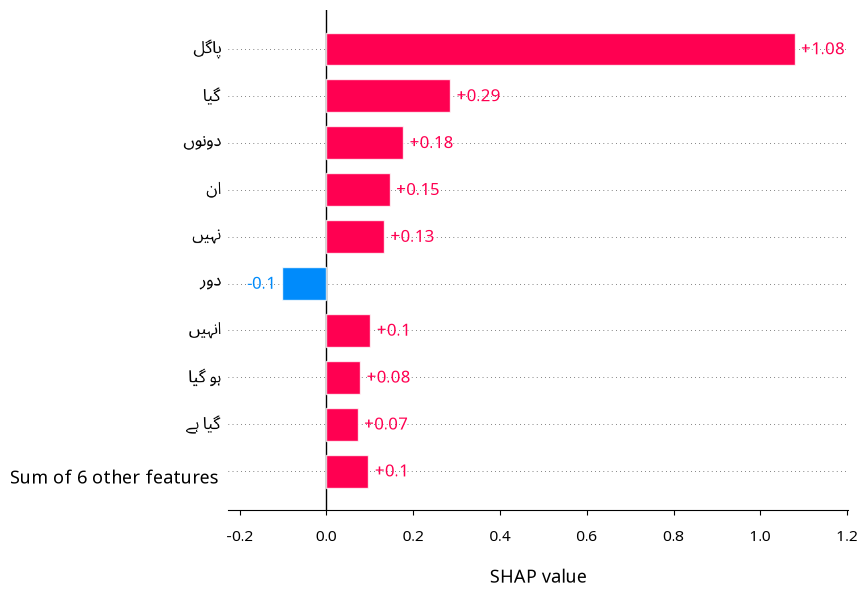


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                   PREDICTION: Offensive
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﭘﺎﮔﻞ | Value: +1.0789
----------------------------------------
ﭘﺎﮔﻞ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﻧﮯ ﭘﯿﺶ ﮔﻮﺋﯽ "Offensive" ﭘﺮ ﻣﺜﺒﺖ ﺍﺛﺮ ﮈﺍﻻ ﮐﯿﻮﻧﮑﮧ ﺍﺭﺩﻭ ﺯﺑﺎﻥ ﻣﯿﮟ ﯾﮧ ﻟﻔﻆ ﺍﮐﺜﺮ ﻣﻨﻔﯽ ﺍﻭﺭ ﺗﻮﮨﯿﻦ ﺁﻣﯿﺰ ﻣﻌﻨﯽ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﺎ ﮨﮯ، ﺟﺲ ﺳﮯ ﯾﮧ ﺑﺎﺕ ﺳﺎﻣﻨﮯ ﺁﺗﯽ ﮨﮯ ﮐﮧ ﺟﻤﻠﮯ ﯾﺎ ﻣﺘﻦ ﻣﯿﮟ ﺍﺱ ﻟﻔﻆ ﮐﺎ ﺍﺳﺘﻌﻤﺎﻝ ﺍﺳﮯ ﺯﯾﺎﺩﮦ ﺣﻤﻠﮧ ﺁﻣﯿﺰ ﯾﺎ ﻏﯿﺮ ﻣﻨﺎﺳﺐ ﺑﻨﺎﺗﺎ ﮨﮯ۔
----------------------------------------


[INFO] Generating English plot...

[INFO] Translating features to English...

[TRANS

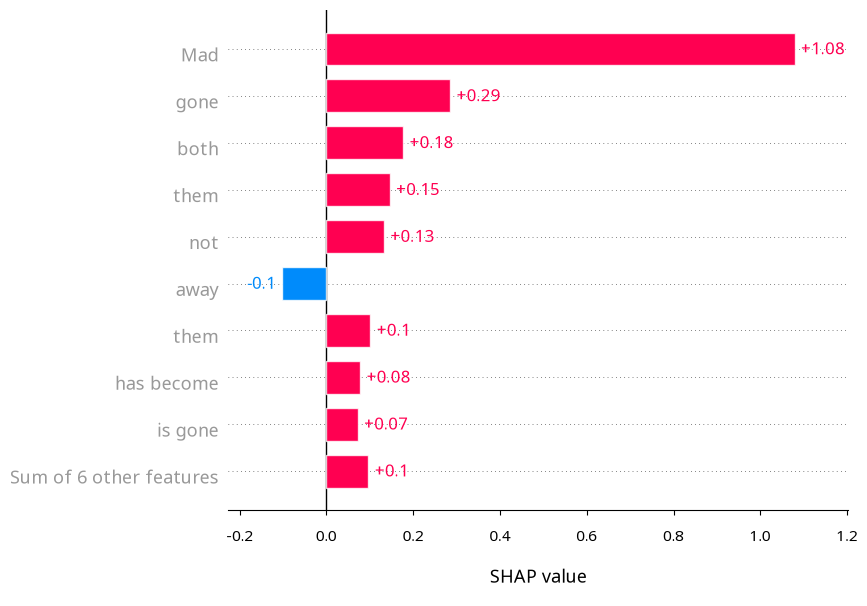


                              ENGLISH EXPLANATIONS                              

Translated Sample: Stay away from both of them, I don't know what has happened to them, they must be crazy.
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                             PREDICTION: Offensive                              
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: Mad | Value: +1.0789
----------------------------------------
The Urdu feature 'Mad' has a positive impact on the model output for the prediction 'Offensive' with a SHAP value of +1.0789, indicating that the presence of this feature increases the likelihood of the model predicting 'Offensive'. This suggests that the word 'Mad' is often associated with

In [59]:

# ============================================================
# CELL 2: BAR PLOT - Feature Importance
# ============================================================

# >>> CHANGE YOUR TEXT HERE <<<
sample_text = "ان دونوں سے دور رہو پتہ نہیں کیا ہو گیا ہے انہیں، پاگل ہیں شاید"
class_id = 1  # 0=Normal, 1=Offensive, 2=Hate
max_features = 10

print("\n" + "="*80)
print("📊 BAR PLOT - Feature Importance")
print("="*80)
print(f"Text: {sample_text}")
print(f"Target Class: {class_names[class_id]}")
print("-"*80)

# Get SHAP values
shap_exp, vec, _ = get_shap_for_sample(sample_text, class_id)

if shap_exp is not None:
    # Get prediction
    pred = model.predict(vec.reshape(1, -1))[0]
    pred_probs = model.predict_proba(vec.reshape(1, -1))[0]
    print(f"Model Prediction: {class_names[pred]}")
    for i, prob in enumerate(pred_probs):
        print(f"  {class_names[i]}: {prob:.3f}")
    
    # Generate RTL Bar Plot
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp,
        prediction_label=class_names[class_id],
        plot_fn=bar,
        sample_text=sample_text,
        max_features=max_features,
        allow_positive_negative_split=True
    )
    plt.show()
else:
    print("No features found in this text")



🌊 WATERFALL PLOT - Prediction Breakdown
Text: فراڈیا پیر کتا کمینا جاہل لوگوں کو بیوقوف بنا رہا ہے
Target Class: Offensive
--------------------------------------------------------------------------------
Model Prediction: Offensive
  Normal: 0.018
  Offensive: 0.615
  Hate: 0.367

                             URDU SHAP EXPLANATIONS                             
                             Prediction: Offensive                              

[GENERATING URDU SHAP PLOT...]


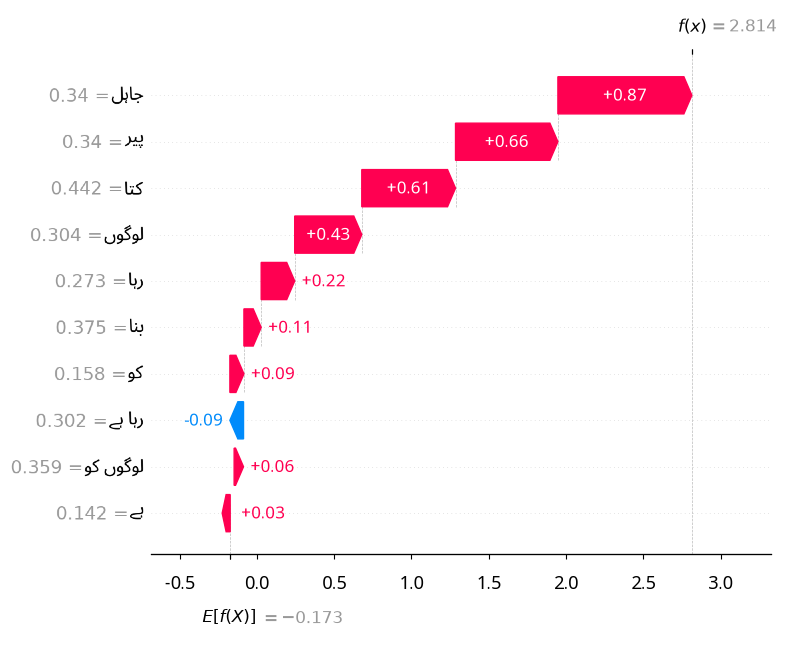


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                   PREDICTION: Offensive
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﺟﺎﮨﻞ | Value: +0.8669
----------------------------------------
ﻟﻔﻆ "ﺟﺎﮨﻞ" ﮐﯽ ﻣﻮﺟﻮﺩﮔﯽ ﭘﯿﺸﻦ ﮔﻮﺋﯽ "Offensive" ﮐﻮ ﻣﺜﺒﺖ ﻃﻮﺭ ﭘﺮ ﻣﺘﺎﺛﺮ ﮐﺮﺗﯽ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﺭﺩﻭ ﺯﺑﺎﻥ ﻣﯿﮟ ﺍﮐﺜﺮ ﻣﻨﻔﯽ ﻣﻌﻨﯽ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﺎ ﮨﮯ، ﺟﺲ ﺳﮯ ﺍﯾﮏ ﻣﻨﻔﯽ ﯾﺎ ﺗﻮﮨﯿﻦ ﺁﻣﯿﺰ ﻣﻌﻨﯽ ﺑﺮﺁﻣﺪ ﮨﻮﺗﺎ ﮨﮯ۔ ﺍﺱ ﻟﻔﻆ ﮐﺎ ﺍﺳﺘﻌﻤﺎﻝ ﺍﮐﺜﺮ ﮐﺴﯽ ﺷﺨﺺ ﮐﯽ ﻏﯿﺮ ﺗﻌﻠﯿﻢ ﯾﺎ ﺑﮯ ﺳﻤﺠﮭﯽ ﮐﯽ ﻃﺮﻑ ﺍﺷﺎﺭﮦ ﮐﺮﺗﺎ ﮨﮯ، ﺟﻮ ﮐﮧ ﺍﮐﺜﺮ ﺗﻮﮨﯿﻦ ﺁﻣﯿﺰ ﯾﺎ ﻏﯿﺮ ﻣﺤﺘﺮﻣﺎﻧﮧ ﺍﻧﺪﺍﺯ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﺎ ﮨﮯ۔ ﺍﺱ ﻟﯿﮯ، ﻣﺎﮈﻝ "ﺟﺎﮨﻞ" ﮐﻮ ﺍﯾﮏ ﺍﯾﺴﺎ ﻟﻔﻆ ﺳﻤﺠﮭﺘﺎ

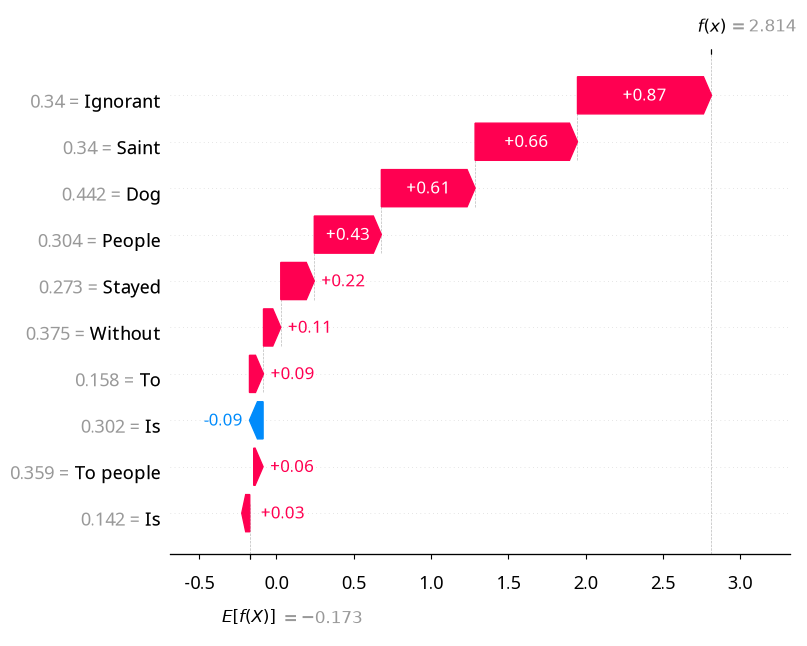


                              ENGLISH EXPLANATIONS                              

Translated Sample: The fraudster pir is fooling the ignorant people
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                             PREDICTION: Offensive                              
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: Ignorant | Value: +0.8669
----------------------------------------
The Urdu feature 'Ignorant' has a significant positive impact on the model's prediction of 'Offensive', with a SHAP value of +0.8669, indicating that the presence of this feature increases the likelihood of the model output being 'Offensive'. This suggests that the model has learned to associate ignorance or a lack of knowle

In [73]:

# ============================================================
# CELL 3: WATERFALL PLOT - Prediction Breakdown
# ============================================================

# >>> CHANGE YOUR TEXT HERE <<<
sample_text = "فراڈیا پیر کتا کمینا جاہل لوگوں کو بیوقوف بنا رہا ہے"
class_id = 1  # 0=Normal, 1=Offensive, 2=Hate
max_features = 15

print("\n" + "="*80)
print("🌊 WATERFALL PLOT - Prediction Breakdown")
print("="*80)
print(f"Text: {sample_text}")
print(f"Target Class: {class_names[class_id]}")
print("-"*80)

# Get SHAP values
shap_exp, vec, _ = get_shap_for_sample(sample_text, class_id)

if shap_exp is not None:
    # Get prediction
    pred = model.predict(vec.reshape(1, -1))[0]
    pred_probs = model.predict_proba(vec.reshape(1, -1))[0]
    print(f"Model Prediction: {class_names[pred]}")
    for i, prob in enumerate(pred_probs):
        print(f"  {class_names[i]}: {prob:.3f}")
    
    # Generate RTL Waterfall Plot
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp,
        prediction_label=class_names[class_id],
        plot_fn=waterfall,
        sample_text=sample_text,
        max_features=max_features
    )
    plt.show()
else:
    print("No features found in this text")


## FORCE PLOT TESTING


💪 FORCE PLOT - Interactive Visualization
Text: یاسین کے جاہلانہ دلائل کو ماننے والے بھی جاھل ہیں شاہ صاحب کی گفتگو علمی ہے
Target Class: Hate
Max Features: 5
--------------------------------------------------------------------------------
Model Prediction: Offensive
  Normal: 0.248
  Offensive: 0.448
  Hate: 0.304

📊 Top 5 features:
------------------------------------------------------------
🔴 علمی                        -0.501 ← AWAY
🟢 والے                        +0.476 → TOWARD
🔴 صاحب                        -0.381 ← AWAY
🔴 صاحب کی                     -0.323 ← AWAY
🟢 ماننے                       +0.314 → TOWARD

🎨 Generating RTL Force Plot...
💡 Note: Force plot is interactive - hover over bars for details

                             URDU SHAP EXPLANATIONS                             
                                Prediction: Hate                                

[GENERATING URDU SHAP PLOT...]


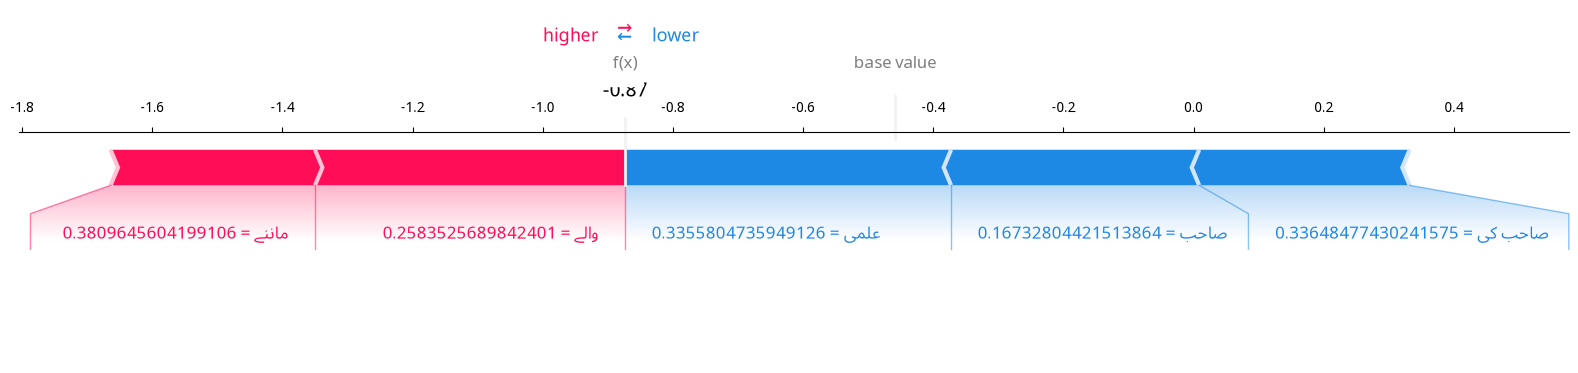


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                        PREDICTION: Hate
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﻋﻠﻤﯽ | Value: -0.5008
----------------------------------------
ﻋﻠﻤﯽ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﻧﮯ ﭘﯿﺶ ﮔﻮﺋﯽ "ﻧﻔﺮﺕ" ﭘﺮ ﻣﻨﻔﯽ ﺍﺛﺮ ﮈﺍﻻ ﮐﯿﻮﻧﮑﮧ ﻋﻠﻤﯽ ﻣﺒﺎﺣﺜﻮﮞ ﻣﯿﮟ ﻣﻨﻄﻘﯽ ﺍﻭﺭ ﻋﻘﻞ ﭘﺮﺳﺖ ﺍﻧﺪﺍﺯ ﮐﺎ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﺎ ﮨﮯ ﺟﻮ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﺍﻭﺭ ﻣﻨﻔﯽ ﺟﺬﺑﺎﺕ ﮐﻮ ﮐﻢ ﮐﺮﺗﺎ ﮨﮯ۔ ﻋﻠﻤﯽ ﻣﻮﺿﻮﻋﺎﺕ ﭘﺮ ﺑﺎﺕ ﭼﯿﺖ ﮐﺮﻧﮯ ﺳﮯ ﻟﻮﮒ ﻣﻨﻄﻘﯽ ﻃﻮﺭ ﭘﺮ ﺳﻮﭼﺘﮯ ﮨﯿﮟ ﺍﻭﺭ ﺍﻥ ﮐﮯ ﺧﯿﺎﻻﺕ ﻣﯿﮟ ﻧﻔﺮﺕ ﺍﻭﺭ ﺗﻌﺼﺐ ﮐﻢ ﮨﻮﺗﺎ ﮨﮯ، ﺟﺲ ﺳﮯ ﭘﯿﺶ ﮔﻮﺋﯽ "ﻧﻔﺮﺕ" ﻣﯿﮟ ﮐﻤﯽ ﺁﺗﯽ ﮨﮯ۔
----------------------------------------


[INFO] Generating E

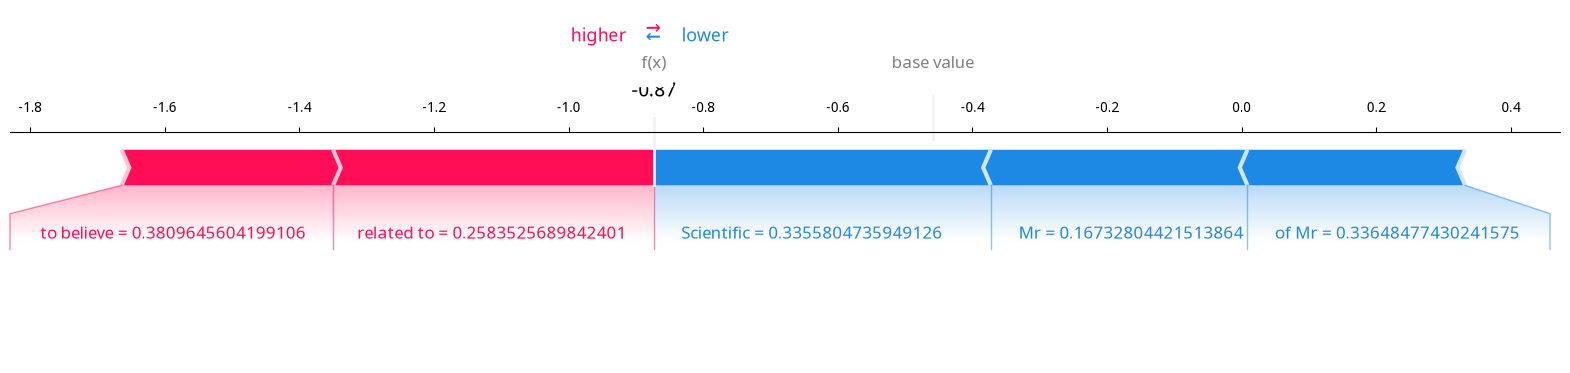


                              ENGLISH EXPLANATIONS                              

Translated Sample: The fraudster pir is fooling the ignorant people
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                               PREDICTION: Nafrat                               
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: Scientific | Value: -0.5008
----------------------------------------
The Urdu feature 'Scientific' (SHAP value: -0.5008) negatively impacts the model output for the prediction 'Hate' (Nafrat) because it suggests that the presence of scientific content reduces the likelihood of a hate-filled response. In other words, when the input text contains scientific terminology or concepts, the model 

In [76]:
# ============================================================
# CELL 4: FORCE PLOT - Interactive Visualization (with 5 features)
# ============================================================

# >>> CHANGE YOUR TEXT HERE <<<
sample_text = "یاسین کے جاہلانہ دلائل کو ماننے والے بھی جاھل ہیں شاہ صاحب کی گفتگو علمی ہے"
class_id = 2  # 0=Normal, 1=Offensive, 2=Hate
max_features = 5  # Only show top 5 features

print("\n" + "="*80)
print("💪 FORCE PLOT - Interactive Visualization")
print("="*80)
print(f"Text: {sample_text}")
print(f"Target Class: {class_names[class_id]}")
print(f"Max Features: {max_features}")
print("-"*80)

# Get SHAP values
shap_exp, vec, _ = get_shap_for_sample(sample_text, class_id)

if shap_exp is not None:
    # Get prediction
    pred = model.predict(vec.reshape(1, -1))[0]
    pred_probs = model.predict_proba(vec.reshape(1, -1))[0]
    print(f"Model Prediction: {class_names[pred]}")
    for i, prob in enumerate(pred_probs):
        print(f"  {class_names[i]}: {prob:.3f}")
    
    # Limit to top features
    if len(shap_exp.values) > max_features:
        # Get top features by absolute SHAP value
        top_indices = np.argsort(np.abs(shap_exp.values))[::-1][:max_features]
        shap_exp_top = shap.Explanation(
            values=shap_exp.values[top_indices],
            base_values=shap_exp.base_values,
            data=shap_exp.data[top_indices] if hasattr(shap_exp, 'data') else None,
            feature_names=[shap_exp.feature_names[i] for i in top_indices]
        )
    else:
        shap_exp_top = shap_exp
    
    # Print top features
    print(f"\n📊 Top {max_features} features:")
    print("-" * 60)
    for name, val in zip(shap_exp_top.feature_names, shap_exp_top.values):
        direction = "→ TOWARD" if val > 0 else "← AWAY"
        emoji = "🟢" if val > 0 else "🔴"
        print(f"{emoji} {name:<25} {val:>+8.3f} {direction}")
    
    # Generate RTL Force Plot with limited features
    print("\n🎨 Generating RTL Force Plot...")
    print("💡 Note: Force plot is interactive - hover over bars for details")
    
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp_top,
        prediction_label=class_names[class_id],
        plot_fn=force,
        sample_text=sample_text,
        max_features=max_features
    )
    
    # Print summary
    print("\n📊 Force Plot Summary:")
    print("-" * 60)
    print(f"Base Value: {shap_exp_top.base_values:.3f}")
    print(f"Total SHAP: {sum(shap_exp_top.values):.3f}")
    print(f"Final Score: {shap_exp_top.base_values + sum(shap_exp_top.values):.3f}")
    print(f"Predicted Class: {class_names[pred]} (Probability: {pred_probs[class_id]:.3f})")
    
    # Show feature breakdown
    print(f"\n🔑 Feature Breakdown (Top {max_features}):")
    print("-" * 60)
    positive_features = [(name, val) for name, val in zip(shap_exp_top.feature_names, shap_exp_top.values) if val > 0]
    negative_features = [(name, val) for name, val in zip(shap_exp_top.feature_names, shap_exp_top.values) if val < 0]
    
    if positive_features:
        print("\n📈 Features pushing TOWARD Hate speech:")
        for name, val in sorted(positive_features, key=lambda x: x[1], reverse=True):
            print(f"   ✅ {name}: +{val:.3f}")
    
    if negative_features:
        print("\n📉 Features pushing AWAY from Hate speech:")
        for name, val in sorted(negative_features, key=lambda x: x[1]):
            print(f"   ❌ {name}: {val:.3f}")
    
    # Analyze specific offensive words
    print("\n🔍 Offensive Word Analysis:")
    print("-" * 60)
    offensive_words = ['جاہلانہ', 'جاھل', 'یاسین', 'شاہ']
    found_offensive = []
    for word in offensive_words:
        if word in sample_text:
            found_offensive.append(word)
            # Check if word is in features
            word_found = False
            for feature_name in shap_exp_top.feature_names:
                if word in feature_name:
                    word_found = True
                    for name, val in zip(shap_exp_top.feature_names, shap_exp_top.values):
                        if name == feature_name:
                            print(f"   • '{word}' → Feature: '{feature_name}' SHAP: {val:+.3f}")
                            break
            if not word_found:
                print(f"   • '{word}' → Not in top {max_features} features")
    
    # Interpretation
    print("\n💡 INTERPRETATION:")
    print("-" * 60)
    if positive_features:
        print(f"The text shows signs of Hate speech due to words like: {', '.join([name for name, _ in positive_features[:3]])}")
    if negative_features:
        print(f"Some words like: {', '.join([name for name, _ in negative_features[:3]])} are pushing away from Hate speech")
    
else:
    print("❌ No features found in this text")
    print("\n💡 POSSIBLE REASONS:")
    print("   • The words in your text are not in the training vocabulary")
    print("   • Try using character n-grams to capture unseen words")
    print("   • Increase max_features in the vectorizer")

In [ ]:
# ============================================================
# CELL 4: FORCE PLOT - Interactive Visualization (with 5 features)
# ============================================================

# >>> CHANGE YOUR TEXT HERE <<<
sample_text = "یاسین کے جاہلانہ دلائل کو ماننے والے بھی جاھل ہیں شاہ صاحب کی گفتگو علمی ہے"
class_id = 2  # 0=Normal, 1=Offensive, 2=Hate
max_features = 5  # Only show top 5 features

print("\n" + "="*80)
print("💪 FORCE PLOT - Interactive Visualization")
print("="*80)
print(f"Text: {sample_text}")
print(f"Target Class: {class_names[class_id]}")
print(f"Max Features: {max_features}")
print("-"*80)

# Get SHAP values
shap_exp, vec, _ = get_shap_for_sample(sample_text, class_id)

if shap_exp is not None:
    # Get prediction
    pred = model.predict(vec.reshape(1, -1))[0]
    pred_probs = model.predict_proba(vec.reshape(1, -1))[0]
    print(f"Model Prediction: {class_names[pred]}")
    for i, prob in enumerate(pred_probs):
        print(f"  {class_names[i]}: {prob:.3f}")
    
    # Limit to top features
    if len(shap_exp.values) > max_features:
        # Get top features by absolute SHAP value
        top_indices = np.argsort(np.abs(shap_exp.values))[::-1][:max_features]
        shap_exp_top = shap.Explanation(
            values=shap_exp.values[top_indices],
            base_values=shap_exp.base_values,
            data=shap_exp.data[top_indices] if hasattr(shap_exp, 'data') else None,
            feature_names=[shap_exp.feature_names[i] for i in top_indices]
        )
    else:
        shap_exp_top = shap_exp
    
    # Print top features
    print(f"\n📊 Top {max_features} features:")
    print("-" * 60)
    for name, val in zip(shap_exp_top.feature_names, shap_exp_top.values):
        direction = "→ TOWARD" if val > 0 else "← AWAY"
        emoji = "🟢" if val > 0 else "🔴"
        print(f"{emoji} {name:<25} {val:>+8.3f} {direction}")
    
    # Generate RTL Force Plot with limited features
    print("\n🎨 Generating RTL Force Plot...")
    print("💡 Note: Force plot is interactive - hover over bars for details")
    
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp_top,
        prediction_label=class_names[class_id],
        plot_fn=force,
        sample_text=sample_text,
        max_features=max_features
    )
    
    # Print summary
    print("\n📊 Force Plot Summary:")
    print("-" * 60)
    print(f"Base Value: {shap_exp_top.base_values:.3f}")
    print(f"Total SHAP: {sum(shap_exp_top.values):.3f}")
    print(f"Final Score: {shap_exp_top.base_values + sum(shap_exp_top.values):.3f}")
    print(f"Predicted Class: {class_names[pred]} (Probability: {pred_probs[class_id]:.3f})")
    
    # Show feature breakdown
    print(f"\n🔑 Feature Breakdown (Top {max_features}):")
    print("-" * 60)
    positive_features = [(name, val) for name, val in zip(shap_exp_top.feature_names, shap_exp_top.values) if val > 0]
    negative_features = [(name, val) for name, val in zip(shap_exp_top.feature_names, shap_exp_top.values) if val < 0]
    
    if positive_features:
        print("\n📈 Features pushing TOWARD Hate speech:")
        for name, val in sorted(positive_features, key=lambda x: x[1], reverse=True):
            print(f"   ✅ {name}: +{val:.3f}")
    
    if negative_features:
        print("\n📉 Features pushing AWAY from Hate speech:")
        for name, val in sorted(negative_features, key=lambda x: x[1]):
            print(f"   ❌ {name}: {val:.3f}")
    
    # Analyze specific offensive words
    print("\n🔍 Offensive Word Analysis:")
    print("-" * 60)
    offensive_words = ['جاہلانہ', 'جاھل', 'یاسین', 'شاہ']
    found_offensive = []
    for word in offensive_words:
        if word in sample_text:
            found_offensive.append(word)
            # Check if word is in features
            word_found = False
            for feature_name in shap_exp_top.feature_names:
                if word in feature_name:
                    word_found = True
                    for name, val in zip(shap_exp_top.feature_names, shap_exp_top.values):
                        if name == feature_name:
                            print(f"   • '{word}' → Feature: '{feature_name}' SHAP: {val:+.3f}")
                            break
            if not word_found:
                print(f"   • '{word}' → Not in top {max_features} features")
    
    # Interpretation
    print("\n💡 INTERPRETATION:")
    print("-" * 60)
    if positive_features:
        print(f"The text shows signs of Hate speech due to words like: {', '.join([name for name, _ in positive_features[:3]])}")
    if negative_features:
        print(f"Some words like: {', '.join([name for name, _ in negative_features[:3]])} are pushing away from Hate speech")
    
else:
    print("❌ No features found in this text")
    print("\n💡 POSSIBLE REASONS:")
    print("   • The words in your text are not in the training vocabulary")
    print("   • Try using character n-grams to capture unseen words")
    print("   • Increase max_features in the vectorizer")


💪 FORCE PLOT with Text Highlighting
Text: یاسین کے جاہلانہ دلائل کو ماننے والے بھی جاھل ہیں شاہ صاحب کی گفتگو علمی ہے
Target Class: Hate
--------------------------------------------------------------------------------
Model Prediction: Offensive
  Normal: 0.211
  Offensive: 0.469
  Hate: 0.321

📊 Top 10 Features:
------------------------------------------------------------
🔴 علمی                        -0.357 ← AWAY
🔴 صاحب                        -0.284 ← AWAY
🟢 جاھل                        +0.263 → TOWARD
🟢 والے                        +0.244 → TOWARD
🟢 کی گفتگو                    +0.218 → TOWARD
🟢 ماننے                       +0.201 → TOWARD
🟢 ہیں                         +0.152 → TOWARD
🟢 ماننے والے                  +0.141 → TOWARD
🔴 صاحب کی                     -0.140 ← AWAY
🟢 یاسین                       +0.119 → TOWARD

🎨 Generating RTL Force Plot...

                             URDU SHAP EXPLANATIONS                             
                                Prediction: Hate       

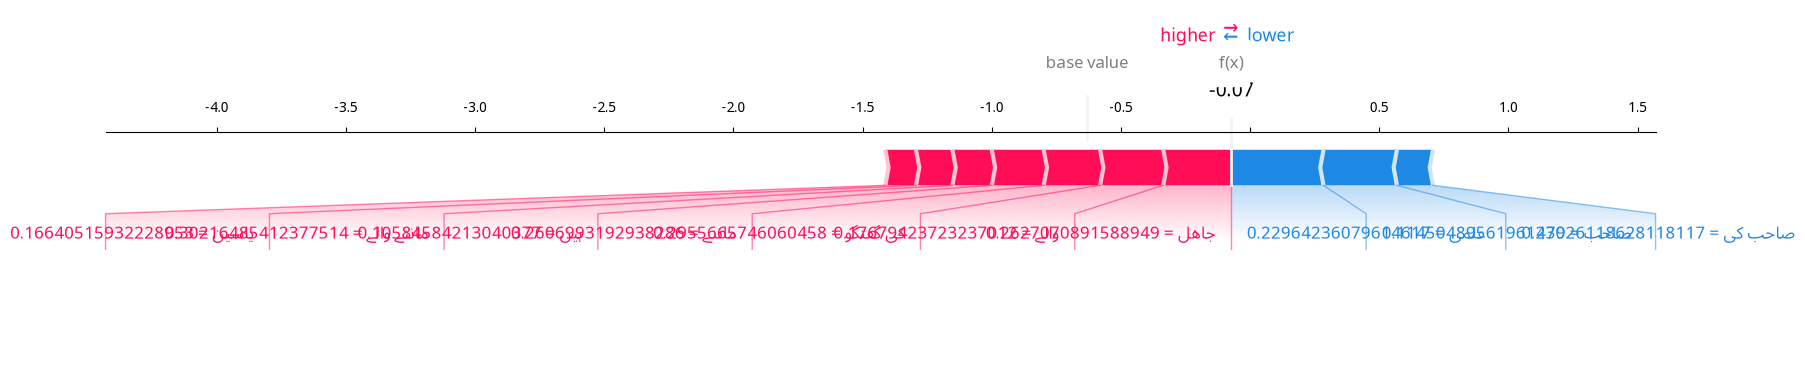


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                        PREDICTION: Hate
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﻋﻠﻤﯽ | Value: -0.3571
----------------------------------------
ﻋﻠﻤﯽ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﻧﮯ ﭘﯿﺶ ﮔﻮﺋﯽ "ﻧﻔﺮﺕ" ﭘﺮ ﻣﻨﻔﯽ ﺍﺛﺮ ﮈﺍﻻ ﮐﯿﻮﻧﮑﮧ ﻋﻠﻤﯽ ﻣﺒﺎﺣﺜﻮﮞ ﻣﯿﮟ ﻣﻨﻄﻘﯽ ﺍﻭﺭ ﻋﻘﻞ ﭘﺮﺳﺖ ﺍﻧﺪﺍﺯ ﮐﯽ ﺿﺮﻭﺭﺕ ﮨﻮﺗﯽ ﮨﮯ ﺟﻮ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﺍﻭﺭ ﻣﻨﻔﯽ ﺟﺬﺑﺎﺕ ﮐﻮ ﮐﻢ ﮐﺮﺗﺎ ﮨﮯ۔ ﻋﻠﻤﯽ ﻣﻮﺿﻮﻋﺎﺕ ﭘﺮ ﺑﺎﺕ ﭼﯿﺖ ﮐﺮﻧﮯ ﺳﮯ ﻟﻮﮒ ﻣﻨﻄﻘﯽ ﻃﻮﺭ ﭘﺮ ﺳﻮﭼﺘﮯ ﮨﯿﮟ ﺍﻭﺭ ﺍﻥ ﮐﮯ ﺧﯿﺎﻻﺕ ﻣﯿﮟ ﺗﻮﺍﺯﻥ ﺁﺗﺎ ﮨﮯ، ﺟﺲ ﺳﮯ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﺑﯿﺎﻧﺎﺕ ﮐﻢ ﮨﻮﺗﮯ ﮨﯿﮟ۔ ﺍﺱ ﻟﯿﮯ ﻋﻠﻤﯽ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﮐﺎ ﻣﻨﻔﯽ ﺍﺛﺮ ﻧﻔﺮﺕ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﮐﻮ ﮐﻢ ﮐﺮﺗﺎ ﮨﮯ۔
-----------

findfont: Failed to find font weight bold, now using 400.



[INFO] Exiting. Thank you!

📝 Colored Text - Hate Class:
🔴 Red = Pushes TOWARD | 🔵 Blue = Pushes AWAY | ⬛ Black = No impact
--------------------------------------------------------------------------------
یاسین کے جاہلانہ دلائل کو ماننے والے بھی جاھل ہیں شاہ صاحب کی گفتگو علمی ہے

🎨 Creating Highlighted Text Visualization...


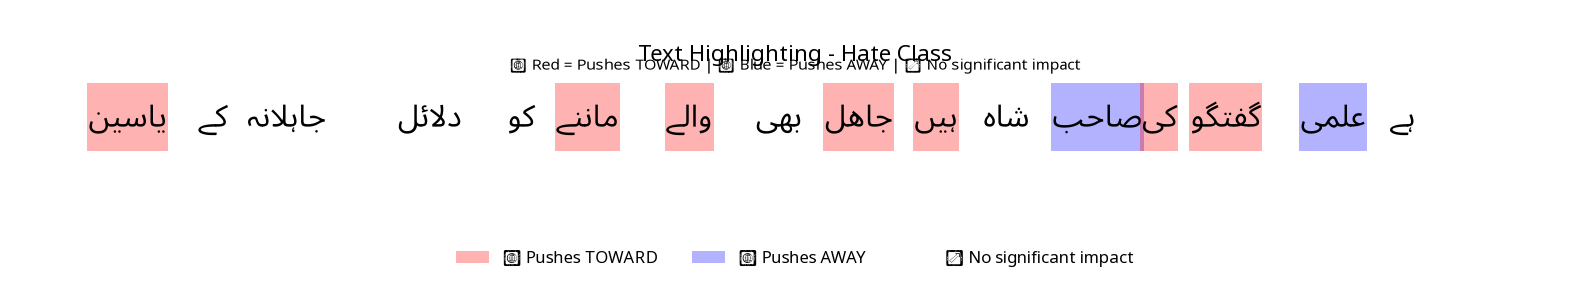


📊 Detailed Summary:
------------------------------------------------------------
Base Value: -0.631
Total SHAP: 0.558
Final Score: -0.073
Predicted Class: Offensive (Probability: 0.321)

🔴 Words pushing TOWARD Hate (RED):
   • جاھل: +0.263
   • والے: +0.244
   • کی گفتگو: +0.218
   • ماننے: +0.201
   • ہیں: +0.152
   • ماننے والے: +0.141
   • یاسین: +0.119

🔵 Words pushing AWAY from Hate (BLUE):
   • علمی: -0.357
   • صاحب: -0.284
   • صاحب کی: -0.140

✅ Analysis complete!


In [81]:
# ============================================================
# CELL 4: FORCE PLOT WITH SIMPLE TEXT HIGHLIGHTING
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
import numpy as np

def print_colored_text(sample_text, feature_names, shap_values, class_name):
    """
    Print the sample text with colored words in console
    """
    # Create color mapping
    color_map = {}
    for name, val in zip(feature_names, shap_values):
        if val > 0:
            color_map[name] = ('red', val, 'TOWARD')
        else:
            color_map[name] = ('blue', val, 'AWAY')
    
    print(f"\n📝 Colored Text - {class_name} Class:")
    print("="*80)
    print("🔴 Red = Pushes TOWARD | 🔵 Blue = Pushes AWAY | ⬛ Black = No impact")
    print("-"*80)
    
    # Print each word with color
    colored_words = []
    for word in sample_text.split():
        found = False
        for feature, (color, val, direction) in color_map.items():
            if feature in word or word in feature:
                if color == 'red':
                    colored_words.append(f'\033[91m{word}\033[0m')  # Red
                else:
                    colored_words.append(f'\033[94m{word}\033[0m')  # Blue
                found = True
                break
        if not found:
            colored_words.append(word)
    
    # Print the colored text
    print(' '.join(colored_words))
    print("="*80)
    
    return color_map

def create_simple_highlighted_visualization(sample_text, feature_names, shap_values, class_name):
    """
    Create a simple matplotlib visualization with highlighted words
    Like a highlighter pen - just colored background, no boxes or borders
    """
    # Create color mapping
    color_map = {}
    for name, val in zip(feature_names, shap_values):
        if val > 0:
            color_map[name] = ('red', val)
        else:
            color_map[name] = ('blue', val)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 3))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    # Add title
    ax.text(0.5, 0.92, f'Text Highlighting - {class_name} Class', 
            transform=ax.transAxes, fontsize=16, fontweight='bold',
            ha='center', va='top')
    ax.text(0.5, 0.85, '🔴 Red = Pushes TOWARD | 🔵 Blue = Pushes AWAY | ⬛ No significant impact', 
            transform=ax.transAxes, fontsize=11, ha='center', va='top')
    
    # Position for text
    x_pos = 0.05
    y_pos = 0.55
    font_size = 22
    
    # Process each word
    for word in sample_text.split():
        found = False
        highlight_color = None
        
        # Check if word or its variants are in color_map
        for feature, (color, val) in color_map.items():
            if feature in word or word in feature:
                highlight_color = color
                found = True
                break
        
        # Create text with highlight (like a highlighter pen)
        if highlight_color == 'red':
            # Red highlight - just colored background, no border
            ax.text(x_pos, y_pos, word, 
                   transform=ax.transAxes,
                   fontsize=font_size, 
                   color='black',  # Keep text black
                   fontweight='bold',
                   bbox=dict(boxstyle='square,pad=0.05', 
                            facecolor='red', 
                            alpha=0.3,  # Semi-transparent like highlighter
                            edgecolor='none',  # No border
                            linewidth=0))  # No border width
        elif highlight_color == 'blue':
            # Blue highlight - just colored background, no border
            ax.text(x_pos, y_pos, word, 
                   transform=ax.transAxes,
                   fontsize=font_size, 
                   color='black',  # Keep text black
                   fontweight='bold',
                   bbox=dict(boxstyle='square,pad=0.05', 
                            facecolor='blue', 
                            alpha=0.3,  # Semi-transparent like highlighter
                            edgecolor='none',  # No border
                            linewidth=0))  # No border width
        else:
            # No highlight
            ax.text(x_pos, y_pos, word, 
                   transform=ax.transAxes,
                   fontsize=font_size, 
                   color='black',
                   fontweight='normal')
        
        # Update position
        x_pos += len(word) * 0.013 + 0.005
        
        # Wrap text if needed
        if x_pos > 0.95:
            x_pos = 0.05
            y_pos -= 0.1
    
    # Add legend with simple colored patches (no borders)
    legend_elements = [
        patches.Patch(facecolor='red', alpha=0.3, edgecolor='none', label='🔴 Pushes TOWARD'),
        patches.Patch(facecolor='blue', alpha=0.3, edgecolor='none', label='🔵 Pushes AWAY'),
        patches.Patch(facecolor='white', alpha=0.5, edgecolor='none', label='⬛ No significant impact')
    ]
    ax.legend(handles=legend_elements, loc='lower center', 
             bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=12,
             frameon=False)
    
    plt.tight_layout()
    plt.show()

# ============================================================
# MAIN: FORCE PLOT WITH TEXT HIGHLIGHTING
# ============================================================

# >>> CHANGE YOUR TEXT HERE <<<
sample_text = "یاسین کے جاہلانہ دلائل کو ماننے والے بھی جاھل ہیں شاہ صاحب کی گفتگو علمی ہے"
class_id = 2  # 0=Normal, 1=Offensive, 2=Hate
max_features = 10

print("\n" + "="*80)
print("💪 FORCE PLOT with Text Highlighting")
print("="*80)
print(f"Text: {sample_text}")
print(f"Target Class: {class_names[class_id]}")
print("-"*80)

# Get SHAP values
shap_exp, vec, _ = get_shap_for_sample(sample_text, class_id)

if shap_exp is not None:
    # Get prediction
    pred = model.predict(vec.reshape(1, -1))[0]
    pred_probs = model.predict_proba(vec.reshape(1, -1))[0]
    print(f"Model Prediction: {class_names[pred]}")
    for i, prob in enumerate(pred_probs):
        print(f"  {class_names[i]}: {prob:.3f}")
    
    # Limit to top features
    if len(shap_exp.values) > max_features:
        top_indices = np.argsort(np.abs(shap_exp.values))[::-1][:max_features]
        shap_exp_top = shap.Explanation(
            values=shap_exp.values[top_indices],
            base_values=shap_exp.base_values,
            data=shap_exp.data[top_indices] if hasattr(shap_exp, 'data') else None,
            feature_names=[shap_exp.feature_names[i] for i in top_indices]
        )
    else:
        shap_exp_top = shap_exp
    
    # Print top features
    print(f"\n📊 Top {max_features} Features:")
    print("-" * 60)
    for name, val in zip(shap_exp_top.feature_names, shap_exp_top.values):
        direction = "→ TOWARD" if val > 0 else "← AWAY"
        emoji = "🟢" if val > 0 else "🔴"
        print(f"{emoji} {name:<25} {val:>+8.3f} {direction}")
    
    # ============================================================
    # GENERATE RTL FORCE PLOT
    # ============================================================
    
    print("\n🎨 Generating RTL Force Plot...")
    
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp_top,
        prediction_label=class_names[class_id],
        plot_fn=force,
        sample_text=sample_text,
        max_features=max_features
    )
    
    # ============================================================
    # HIGHLIGHT TEXT IN CONSOLE (ANSI colors)
    # ============================================================
    
    # Print colored text in console
    color_map = print_colored_text(
        sample_text, 
        shap_exp_top.feature_names, 
        shap_exp_top.values, 
        class_names[class_id]
    )
    
    # ============================================================
    # CREATE VISUALIZATION WITH HIGHLIGHTED TEXT
    # ============================================================
    
    print("\n🎨 Creating Highlighted Text Visualization...")
    create_simple_highlighted_visualization(
        sample_text,
        shap_exp_top.feature_names,
        shap_exp_top.values,
        class_names[class_id]
    )
    
    # ============================================================
    # DETAILED SUMMARY
    # ============================================================
    
    print("\n📊 Detailed Summary:")
    print("-" * 60)
    print(f"Base Value: {shap_exp_top.base_values:.3f}")
    print(f"Total SHAP: {sum(shap_exp_top.values):.3f}")
    print(f"Final Score: {shap_exp_top.base_values + sum(shap_exp_top.values):.3f}")
    print(f"Predicted Class: {class_names[pred]} (Probability: {pred_probs[class_id]:.3f})")
    
    # Show feature breakdown
    positive_features = [(name, val) for name, val in zip(shap_exp_top.feature_names, shap_exp_top.values) if val > 0]
    negative_features = [(name, val) for name, val in zip(shap_exp_top.feature_names, shap_exp_top.values) if val < 0]
    
    if positive_features:
        print(f"\n🔴 Words pushing TOWARD {class_names[class_id]} (RED):")
        for name, val in sorted(positive_features, key=lambda x: x[1], reverse=True):
            print(f"   • {name}: +{val:.3f}")
    
    if negative_features:
        print(f"\n🔵 Words pushing AWAY from {class_names[class_id]} (BLUE):")
        for name, val in sorted(negative_features, key=lambda x: x[1]):
            print(f"   • {name}: {val:.3f}")
    
    print("\n" + "="*80)
    print("✅ Analysis complete!")
    print("="*80)
    
else:
    print("❌ No features found in this text")

## BEESWARM TESTING


🐝 BEESWARM PLOT - Feature Distribution
Text: اقرار الحسن صاحب نے ننگا کردیا فراڈئے پیر کو
Target Class: Hate
--------------------------------------------------------------------------------

                             URDU SHAP EXPLANATIONS                             
                                Prediction: Hate                                

[GENERATING URDU SHAP PLOT...]


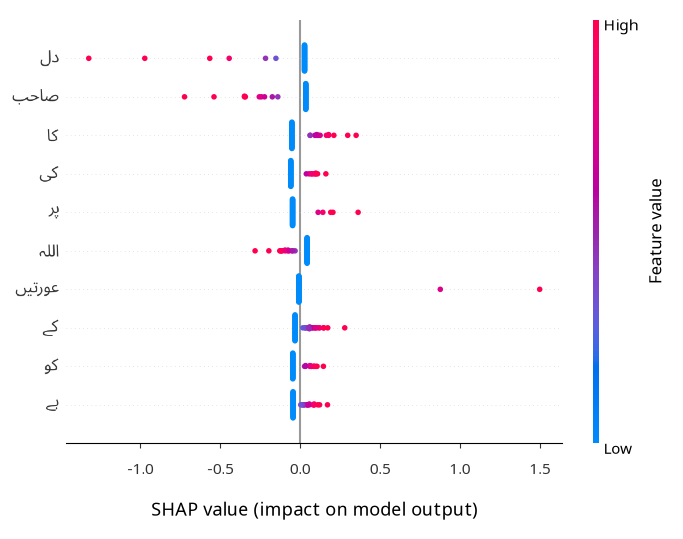


[Urdu Explanation Mode]

[INFO] Skipping RTL explanation.

[INFO] Exiting. Thank you!


In [84]:

# ============================================================
# CELL 5: BEESWARM PLOT - Feature Distribution
# ============================================================

# >>> CHANGE YOUR TEXT HERE <<<
sample_text = "اقرار الحسن صاحب نے ننگا کردیا فراڈئے پیر کو"
class_id = 2  # 0=Normal, 1=Offensive, 2=Hate
max_features = 10

print("\n" + "="*80)
print("🐝 BEESWARM PLOT - Feature Distribution")
print("="*80)
print(f"Text: {sample_text}")
print(f"Target Class: {class_names[class_id]}")
print("-"*80)

# Get SHAP values for multiple samples
shap_exp, vec, _ = get_shap_for_sample(sample_text, class_id)

if shap_exp is not None:
    # Get SHAP values for test samples
    shap_values_all = []
    for i in range(min(50, len(X_test_vec))):
        vec_sample = X_test_vec[i]
        if np.sum(vec_sample) > 0:
            masker = shap.maskers.Independent(data=X_train_vec[:100], max_samples=100)
            class_estimator = model.estimators_[class_id]
            shap_explainer = shap.LinearExplainer(class_estimator, masker=masker)
            shap_val = shap_explainer(vec_sample.reshape(1, -1))
            shap_values_all.append(shap_val.values[0])
    
    if shap_values_all:
        shap_values_all = np.array(shap_values_all)
        
        # Get top features
        top_features_idx = np.argsort(np.abs(shap_values_all).mean(axis=0))[::-1][:max_features]
        top_feature_names = [vectorizer.get_feature_names_out()[i] for i in top_features_idx]
        
        shap_exp_beeswarm = shap.Explanation(
            values=shap_values_all[:, top_features_idx],
            base_values=shap_exp.base_values,
            data=X_test_vec[:len(shap_values_all), top_features_idx],
            feature_names=top_feature_names
        )
        
        # Generate RTL Beeswarm Plot
        explainer_rtl.run_full_analysis(
            shap_values=shap_exp_beeswarm,
            prediction_label=class_names[class_id],
            plot_fn=beeswarm,
            max_features=max_features
        )
        plt.show()
    else:
        print("Not enough samples for beeswarm plot")
else:
    print("No features found in this text")


In [3]:
# ============================================================
# FORCE FONT FOR URDU
# ============================================================

import matplotlib as mpl
from matplotlib import font_manager
import os

# Path to your Urdu font
font_path = r'c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\JameelNooriNastaliq.ttf'

if os.path.exists(font_path):
    # Register the font
    font_manager.fontManager.addfont(font_path)
    prop = font_manager.FontProperties(fname=font_path)
    font_name = prop.get_name()
    
    # Set as default
    mpl.rcParams['font.family'] = font_name
    mpl.rcParams['axes.unicode_minus'] = False
    print(f"✅ Urdu font forced: {font_name}")
else:
    print("⚠️ Urdu font not found at:", font_path)

# Also set in rtl_utils
from shap_rtl.rtl_utils import set_rtl_font_path
if os.path.exists(font_path):
    set_rtl_font_path(font_path)

⚠️ Urdu font not found at: c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\JameelNooriNastaliq.ttf


📊 URDU HATE SPEECH - FORCE PLOT

📂 Loading data...
✅ Dataset loaded: 16341 samples
  Normal: 7895 (48.3%)
  Offensive: 6199 (37.9%)
  Hate: 2247 (13.8%)

🔧 TRAINING MODEL
✅ Model trained!
Train Accuracy: 0.696
Test Accuracy: 0.630

🔤 SETUP RTL EXPLAINER
✅ Created explainer for Normal class
✅ Created explainer for Offensive class
✅ Created explainer for Hate class
[DEBUG] Current language set to: Urdu
[DEBUG] Current language set to: Urdu
[DEBUG] Looking for font for language: Urdu
[DEBUG] Trying language-specific fonts: ['JameelNooriNastaliq.ttf', 'JameelNooriNastaleeq.ttf', 'Jameel Noori Nastaleeq Regular.ttf', 'NotoNastaliqUrdu-Regular.ttf', 'NotoNastaliqUrdu-VariableFont_wght.ttf', 'UrduNastaliq.ttf', 'NafeesNastaleeq.ttf']
[INFO] Found bundled Urdu font: NotoNastaliqUrdu-Regular.ttf
[INFO] Font registered with matplotlib: Noto Nastaliq Urdu
[INFO] Loaded Urdu font: NotoNastaliqUrdu-Regular.ttf
[INFO] Font display name: Noto Nastaliq Urdu

🔤 RTL SHAP Explainer Initialized
   Languag

findfont: Failed to find font weight bold, now using 400.


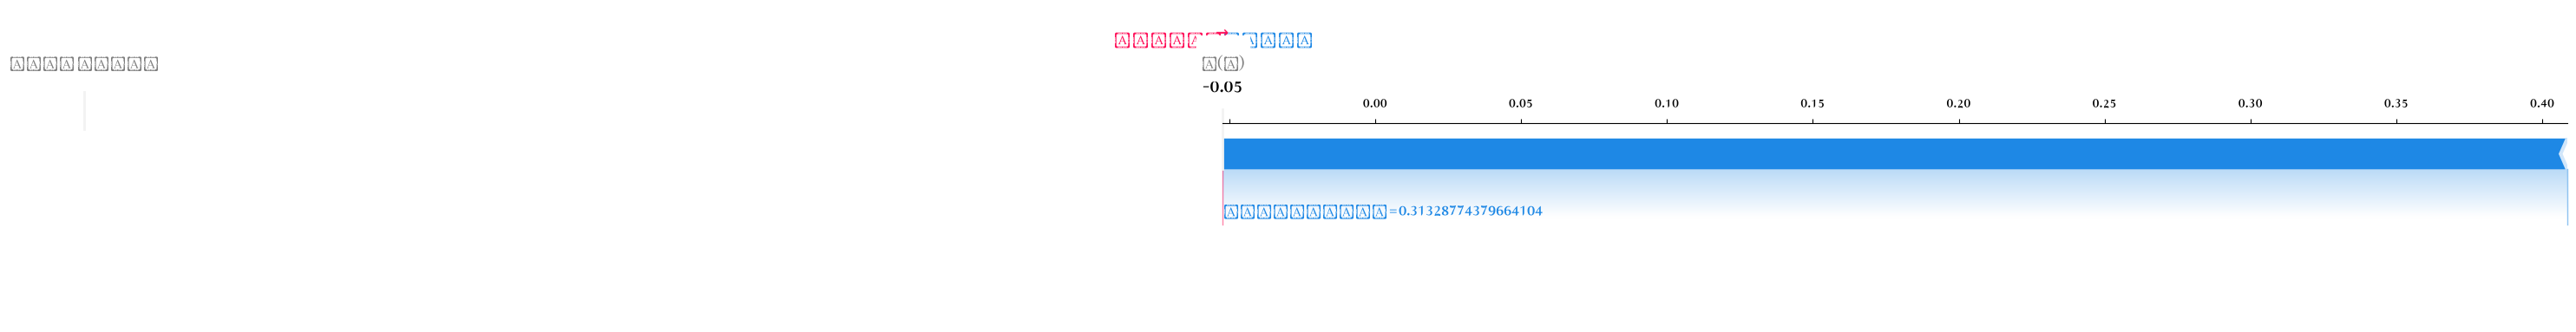


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                        PREDICTION: Hate
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﻋﻠﻤﯽ | Value: -0.4609
----------------------------------------
ﻋﻠﻤﯽ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﻧﮯ ﭘﯿﺶ ﮔﻮﺋﯽ "ﻧﻔﺮﺕ" ﭘﺮ ﻣﻨﻔﯽ ﺍﺛﺮ ﮈﺍﻻ ﮐﯿﻮﻧﮑﮧ ﻋﻠﻤﯽ ﻣﺒﺎﺣﺜﻮﮞ ﻣﯿﮟ ﻣﻨﻄﻘﯽ ﺍﻭﺭ ﻋﻘﻞ ﭘﺮﺳﺘﯽ ﮐﯽ ﺟﺎﺗﯽ ﮨﮯ، ﺟﻮ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﺍﻭﺭ ﻣﻨﻔﯽ ﺟﺬﺑﺎﺕ ﮐﻮ ﮐﻢ ﮐﺮﺗﯽ ﮨﮯ۔ ﻋﻠﻤﯽ ﻣﻮﺿﻮﻋﺎﺕ ﻣﯿﮟ ﺑﺤﺚ ﻭ ﻣﺒﺎﺣﺜﮧ ﮐﺎ ﺍﻧﺪﺍﺯ ﻋﺎﻡ ﻃﻮﺭ ﭘﺮ ﺷﺎﺋﺴﺘﮧ ﺍﻭﺭ ﻣﺤﺘﺮﻣﺎﻧﮧ ﮨﻮﺗﺎ ﮨﮯ، ﺟﺲ ﺳﮯ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﺯﺑﺎﻥ ﮐﮯ ﺍﺳﺘﻌﻤﺎﻝ ﮐﯽ ﺍﻣﮑﺎﻧﺎﺕ ﮐﻢ ﮨﻮ ﺟﺎﺗﯽ ﮨﯿﮟ۔ ﺍﺱ ﻟﯿﮯ، ﻋﻠﻤﯽ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﮐﯽ ﻣﻨﻔﯽ ﺷﺎﭖ ﻗﯿﻤﺖ ﺍﺱ ﺑﺎﺕ ﮐﯽ ﻋﻼﻣﺖ ﮨﮯ ﮐﮧ ﻋﻠﻤﯽ ﻣﻮﺿﻮﻋﺎﺕ ﭘﺮ ﻣ

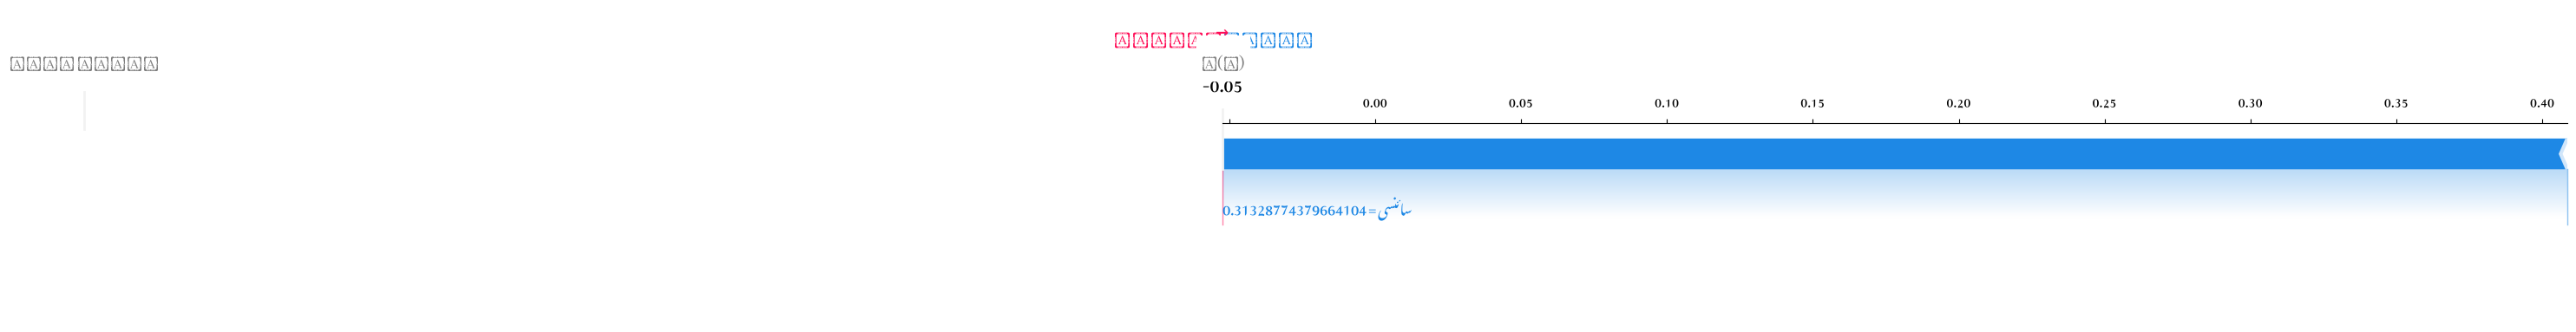


                              ENGLISH EXPLANATIONS                              

Translated Sample: Those who believe in Yasin's ignorant arguments are also ignorant, Mr. Shah's conversation is scientific.
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                               PREDICTION: Nafrat                               
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: Scientific | Value: -0.4609
----------------------------------------
The Urdu feature 'Scientific' (SHAP value: -0.4609) negatively impacts the model output for the prediction 'Hate' (Nafrat) because it suggests that the presence of scientific content reduces the likelihood of a hate-filled sentiment. This implies that when the model 

In [4]:
# ============================================================
# COMPLETE FORCE PLOT - URDU HATE SPEECH DETECTION
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STEP 1: IMPORT RTL LIBRARIES
# ============================================================

from shap_rtl.plots import force, bar, waterfall, beeswarm, heatmap, scatter, decision_plot
from shap_rtl import RTLSHAPExplainer

print("="*80)
print("📊 URDU HATE SPEECH - FORCE PLOT")
print("="*80)

# ============================================================
# STEP 2: LOAD DATA
# ============================================================

print("\n📂 Loading data...")

file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Urdu_HS_dataset.csv'

df = pd.read_csv(file_path)
df = df.dropna(subset=['Comments', 'Label'])
df['Comments'] = df['Comments'].astype(str)

# Map labels to 3 classes
def map_to_three_classes(label):
    label = str(label).lower().strip()
    if 'hate' in label:
        return 2
    elif 'offensive' in label:
        return 1
    elif 'normal' in label:
        return 0
    else:
        try:
            num_label = float(label)
            if num_label == 0:
                return 0
            elif num_label in [1, 3]:
                return 1
            elif num_label in [2, 4]:
                return 2
            else:
                return 1
        except:
            return 0

df['Label'] = df['Label'].astype(str).str.lower().str.strip().apply(map_to_three_classes)
class_names = {0: 'Normal', 1: 'Offensive', 2: 'Hate'}

print(f"✅ Dataset loaded: {len(df)} samples")
for class_id, name in class_names.items():
    count = (df['Label'] == class_id).sum()
    print(f"  {name}: {count} ({count/len(df)*100:.1f}%)")

# ============================================================
# STEP 3: TRAIN MODEL
# ============================================================

print("\n" + "="*80)
print("🔧 TRAINING MODEL")
print("="*80)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['Comments'], df['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['Label']
)

# Vectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), 
    analyzer='word', 
    max_features=1000, 
    min_df=2, 
    max_df=0.95
)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

# Train model
model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, solver='lbfgs')
).fit(X_train_vec, y_train)

print(f"✅ Model trained!")
print(f"Train Accuracy: {model.score(X_train_vec, y_train):.3f}")
print(f"Test Accuracy: {model.score(X_test_vec, y_test):.3f}")

feature_names = list(vectorizer.get_feature_names_out())

# ============================================================
# STEP 4: SETUP RTL EXPLAINER
# ============================================================

print("\n" + "="*80)
print("🔤 SETUP RTL EXPLAINER")
print("="*80)

X_background = X_train_vec[:100]
masker = shap.maskers.Independent(data=X_background, max_samples=100)

# Get SHAP explainer for specific class
def get_class_explainer(class_id):
    class_estimator = model.estimators_[class_id]
    return shap.LinearExplainer(class_estimator, masker=masker)

class_explainers = {}
for class_id in range(3):
    class_explainers[class_id] = get_class_explainer(class_id)
    print(f"✅ Created explainer for {class_names[class_id]} class")

# Create RTL explainer
explainer_rtl = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

print("✅ RTL SHAP explainer ready!")

# ============================================================
# STEP 5: HELPER FUNCTION
# ============================================================

def get_shap_for_sample(sample_text, class_id=1, max_features=10):
    """Get SHAP values for a specific class"""
    vec = vectorizer.transform([sample_text]).toarray()[0]
    present_idx = np.where(vec > 0)[0]
    
    if len(present_idx) == 0:
        return None, None, None
    
    explainer = class_explainers[class_id]
    shap_values = explainer(vec.reshape(1, -1))
    
    present_feature_names = [feature_names[i] for i in present_idx]
    present_shap_values = shap_values.values[0][present_idx]
    present_data = vec[present_idx]
    
    sorted_idx = np.argsort(np.abs(present_shap_values))[::-1]
    sorted_features = [present_feature_names[i] for i in sorted_idx]
    sorted_shap = present_shap_values[sorted_idx]
    sorted_data = present_data[sorted_idx]
    
    shap_exp = shap.Explanation(
        values=sorted_shap,
        base_values=shap_values.base_values[0],
        data=sorted_data,
        feature_names=sorted_features
    )
    
    return shap_exp, vec, model.predict(vec.reshape(1, -1))[0]

print("✅ Helper function ready!")

# ============================================================
# STEP 6: FORCE PLOT - Interactive Visualization
# ============================================================

# >>> CHANGE YOUR TEXT HERE <<<
sample_text = "یاسین کے جاہلانہ دلائل کو ماننے والے بھی جاھل ہیں شاہ صاحب کی گفتگو علمی ہے"
class_id = 2  # 0=Normal, 1=Offensive, 2=Hate
max_features = 5  # Only show top 5 features

print("\n" + "="*80)
print("💪 FORCE PLOT - Interactive Visualization")
print("="*80)
print(f"Text: {sample_text}")
print(f"Target Class: {class_names[class_id]}")
print(f"Max Features: {max_features}")
print("-"*80)

# Get SHAP values
shap_exp, vec, pred = get_shap_for_sample(sample_text, class_id)

if shap_exp is not None:
    # Get prediction probabilities
    pred_probs = model.predict_proba(vec.reshape(1, -1))[0]
    print(f"Model Prediction: {class_names[pred]}")
    for i, prob in enumerate(pred_probs):
        print(f"  {class_names[i]}: {prob:.3f}")
    
    # Limit to top features
    if len(shap_exp.values) > max_features:
        top_indices = np.argsort(np.abs(shap_exp.values))[::-1][:max_features]
        shap_exp_top = shap.Explanation(
            values=shap_exp.values[top_indices],
            base_values=shap_exp.base_values,
            data=shap_exp.data[top_indices] if hasattr(shap_exp, 'data') else None,
            feature_names=[shap_exp.feature_names[i] for i in top_indices]
        )
    else:
        shap_exp_top = shap_exp
    
    # Print top features
    print(f"\n📊 Top {max_features} features:")
    print("-" * 60)
    for name, val in zip(shap_exp_top.feature_names, shap_exp_top.values):
        direction = "→ TOWARD" if val > 0 else "← AWAY"
        emoji = "🟢" if val > 0 else "🔴"
        print(f"{emoji} {name:<25} {val:>+8.3f} {direction}")
    
    # Generate RTL Force Plot
    print("\n🎨 Generating RTL Force Plot...")
    print("💡 Note: Force plot is interactive - hover over bars for details")
    
    # This will now automatically show:
    # 1. Force Plot with RTL text
    # 2. Highlighted text below the plot
    explainer_rtl.run_full_analysis(
        shap_values=shap_exp_top,
        prediction_label=class_names[class_id],
        plot_fn=force,  # ← Updated force function with highlighting
        sample_text=sample_text,  # ← This gets passed to force function
        max_features=max_features
    )
    
    # Summary
    print("\n📊 Force Plot Summary:")
    print("-" * 60)
    print(f"Base Value: {shap_exp_top.base_values:.3f}")
    print(f"Total SHAP: {sum(shap_exp_top.values):.3f}")
    print(f"Final Score: {shap_exp_top.base_values + sum(shap_exp_top.values):.3f}")
    print(f"Predicted Class: {class_names[pred]} (Probability: {pred_probs[class_id]:.3f})")
    
    # Feature breakdown
    print(f"\n🔑 Feature Breakdown (Top {max_features}):")
    print("-" * 60)
    positive_features = [(name, val) for name, val in zip(shap_exp_top.feature_names, shap_exp_top.values) if val > 0]
    negative_features = [(name, val) for name, val in zip(shap_exp_top.feature_names, shap_exp_top.values) if val < 0]
    
    if positive_features:
        print("\n📈 Features pushing TOWARD Hate speech:")
        for name, val in sorted(positive_features, key=lambda x: x[1], reverse=True):
            print(f"   ✅ {name}: +{val:.3f}")
    
    if negative_features:
        print("\n📉 Features pushing AWAY from Hate speech:")
        for name, val in sorted(negative_features, key=lambda x: x[1]):
            print(f"   ❌ {name}: {val:.3f}")
    
    # Offensive word analysis
    print("\n🔍 Offensive Word Analysis:")
    print("-" * 60)
    offensive_words = ['جاہلانہ', 'جاھل', 'یاسین', 'شاہ']
    for word in offensive_words:
        if word in sample_text:
            word_found = False
            for feature_name in shap_exp_top.feature_names:
                if word in feature_name:
                    word_found = True
                    for name, val in zip(shap_exp_top.feature_names, shap_exp_top.values):
                        if name == feature_name:
                            print(f"   • '{word}' → Feature: '{feature_name}' SHAP: {val:+.3f}")
                            break
            if not word_found:
                print(f"   • '{word}' → Not in top {max_features} features")
    
    # Interpretation
    print("\n💡 INTERPRETATION:")
    print("-" * 60)
    if positive_features:
        print(f"The text shows signs of Hate speech due to words like: {', '.join([name for name, _ in positive_features[:3]])}")
    if negative_features:
        print(f"Some words like: {', '.join([name for name, _ in negative_features[:3]])} are pushing away from Hate speech")
    
else:
    print("❌ No features found in this text")

print("\n" + "="*80)
print("✅ FORCE PLOT COMPLETE!")
print("="*80)